# FIFA Player Similarity Project — EDA
**Öğrenci**: Ali


**Amaç:** FIFA 15 datasetini kullanarak benzer oyuncu öneri sistemi için
veri keşfi ve modelleme kararları.

## Çalışma Günlüğü
- **Gün 1 (04/13/2026):** Tanıma ve temizlik
- **Gün 2 (04/14/2026):** Derin analiz
- **Gün 3 (04/15/2026):** Anlam çıkarma ve modelleme kararları

# 📅 Gün 1 — Tanıma ve Temizlik
**Hedef:** Datasetin ne içerdiğini anlamak, çöpü ayırmak, veri tiplerini düzeltmek.

## Görev 1 — Dataset Tanışması
**Süre:** ~45 dk
**Amaç:** Datasetin boyutunu, sütun yapısını ve genel karakterini anlamak.

### Yapacaklarım:
1. Dataseti yükle, shape kontrol et
2. `df.info(verbose=True, show_counts=True)` ile tüm sütunları incele
3. `df.head(3)` ve `df.sample(5)` ile farklı satırları gör
4. 110 sütunu 10 kategoriye ayır (Python'da prefix filtering ile say)
5. Aşağıdaki 5 soruyu cevapla

In [92]:
from re import search

import pandas as pd







In [93]:
df  = pd.read_csv("players_15.csv", low_memory=False)

In [94]:
df.head()

,sofifa_id,player_url,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,...,lcb,cb,rcb,rb,gk,player_face_url,club_logo_url,club_flag_url,nation_logo_url,nation_flag_url
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,CF,93,95,100500000.0,550000.0,27,...,45+3,45+3,45+3,54+3,15+3,https://cdn.sofifa.net/players/158/023/15_120.png,https://cdn.sofifa.net/teams/241/60.png,https://cdn.sofifa.net/flags/es.png,https://cdn.sofifa.net/teams/1369/60.png,https://cdn.sofifa.net/flags/ar.png
1,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,"LW, LM",92,92,79000000.0,375000.0,29,...,52+3,52+3,52+3,57+3,16+3,https://cdn.sofifa.net/players/020/801/15_120.png,https://cdn.sofifa.net/teams/243/60.png,https://cdn.sofifa.net/flags/es.png,https://cdn.sofifa.net/teams/1354/60.png,https://cdn.sofifa.net/flags/pt.png
2,9014,https://sofifa.com/player/9014/arjen-robben/15...,A. Robben,Arjen Robben,"RM, LM, RW",90,90,54500000.0,275000.0,30,...,46+3,46+3,46+3,55+3,14+3,https://cdn.sofifa.net/players/009/014/15_120.png,https://cdn.sofifa.net/teams/21/60.png,https://cdn.sofifa.net/flags/de.png,https://cdn.sofifa.net/teams/105035/60.png,https://cdn.sofifa.net/flags/nl.png
3,41236,https://sofifa.com/player/41236/zlatan-ibrahim...,Z. Ibrahimović,Zlatan Ibrahimović,ST,90,90,52500000.0,275000.0,32,...,55+3,55+3,55+3,56+3,17+3,https://cdn.sofifa.net/players/041/236/15_120.png,https://cdn.sofifa.net/teams/73/60.png,https://cdn.sofifa.net/flags/fr.png,https://cdn.sofifa.net/teams/1363/60.png,https://cdn.sofifa.net/flags/se.png
4,167495,https://sofifa.com/player/167495/manuel-neuer/...,M. Neuer,Manuel Peter Neuer,GK,90,90,63500000.0,300000.0,28,...,38+3,38+3,38+3,36+3,87+3,https://cdn.sofifa.net/players/167/495/15_120.png,https://cdn.sofifa.net/teams/21/60.png,https://cdn.sofifa.net/flags/de.png,https://cdn.sofifa.net/teams/1337/60.png,https://cdn.sofifa.net/flags/de.png


In [95]:
df.info(verbose=True,show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16155 entries, 0 to 16154
Data columns (total 110 columns):
 #    Column                       Non-Null Count  Dtype  
---   ------                       --------------  -----  
 0    sofifa_id                    16155 non-null  int64  
 1    player_url                   16155 non-null  object 
 2    short_name                   16155 non-null  object 
 3    long_name                    16155 non-null  object 
 4    player_positions             16155 non-null  object 
 5    overall                      16155 non-null  int64  
 6    potential                    16155 non-null  int64  
 7    value_eur                    15844 non-null  float64
 8    wage_eur                     15916 non-null  float64
 9    age                          16155 non-null  int64  
 10   dob                          16155 non-null  object 
 11   height_cm                    16155 non-null  int64  
 12   weight_kg                    16155 non-null  int64  
 13  

In [96]:
df.head(5)

,sofifa_id,player_url,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,...,lcb,cb,rcb,rb,gk,player_face_url,club_logo_url,club_flag_url,nation_logo_url,nation_flag_url
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,CF,93,95,100500000.0,550000.0,27,...,45+3,45+3,45+3,54+3,15+3,https://cdn.sofifa.net/players/158/023/15_120.png,https://cdn.sofifa.net/teams/241/60.png,https://cdn.sofifa.net/flags/es.png,https://cdn.sofifa.net/teams/1369/60.png,https://cdn.sofifa.net/flags/ar.png
1,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,"LW, LM",92,92,79000000.0,375000.0,29,...,52+3,52+3,52+3,57+3,16+3,https://cdn.sofifa.net/players/020/801/15_120.png,https://cdn.sofifa.net/teams/243/60.png,https://cdn.sofifa.net/flags/es.png,https://cdn.sofifa.net/teams/1354/60.png,https://cdn.sofifa.net/flags/pt.png
2,9014,https://sofifa.com/player/9014/arjen-robben/15...,A. Robben,Arjen Robben,"RM, LM, RW",90,90,54500000.0,275000.0,30,...,46+3,46+3,46+3,55+3,14+3,https://cdn.sofifa.net/players/009/014/15_120.png,https://cdn.sofifa.net/teams/21/60.png,https://cdn.sofifa.net/flags/de.png,https://cdn.sofifa.net/teams/105035/60.png,https://cdn.sofifa.net/flags/nl.png
3,41236,https://sofifa.com/player/41236/zlatan-ibrahim...,Z. Ibrahimović,Zlatan Ibrahimović,ST,90,90,52500000.0,275000.0,32,...,55+3,55+3,55+3,56+3,17+3,https://cdn.sofifa.net/players/041/236/15_120.png,https://cdn.sofifa.net/teams/73/60.png,https://cdn.sofifa.net/flags/fr.png,https://cdn.sofifa.net/teams/1363/60.png,https://cdn.sofifa.net/flags/se.png
4,167495,https://sofifa.com/player/167495/manuel-neuer/...,M. Neuer,Manuel Peter Neuer,GK,90,90,63500000.0,300000.0,28,...,38+3,38+3,38+3,36+3,87+3,https://cdn.sofifa.net/players/167/495/15_120.png,https://cdn.sofifa.net/teams/21/60.png,https://cdn.sofifa.net/flags/de.png,https://cdn.sofifa.net/teams/1337/60.png,https://cdn.sofifa.net/flags/de.png


In [97]:
df.sample(3)

,sofifa_id,player_url,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,...,lcb,cb,rcb,rb,gk,player_face_url,club_logo_url,club_flag_url,nation_logo_url,nation_flag_url
15094,221613,https://sofifa.com/player/221613/ibrahima-dram...,I. Dramé,Ibrahima Dramé,ST,53,65,50000.0,2000.0,18,...,37,37,37,37,13,https://cdn.sofifa.net/players/221/613/15_120.png,https://cdn.sofifa.net/teams/919/60.png,https://cdn.sofifa.net/flags/no.png,NaN,https://cdn.sofifa.net/flags/sn.png
5552,51620,https://sofifa.com/player/51620/cedric-varraul...,C. Varrault,Cédric Varrault,CB,66,66,210000.0,4000.0,34,...,66,66,66,63,11,https://cdn.sofifa.net/players/051/620/15_120.png,https://cdn.sofifa.net/teams/110569/60.png,https://cdn.sofifa.net/flags/fr.png,NaN,https://cdn.sofifa.net/flags/fr.png
6646,181989,https://sofifa.com/player/181989/andres-rios/1...,A. Ríos,Andrés Lorenzo Ríos,"ST, LW, RW",65,70,600000.0,6000.0,24,...,44,44,44,43,17,https://cdn.sofifa.net/players/181/989/15_120.png,https://cdn.sofifa.net/teams/111654/60.png,https://cdn.sofifa.net/flags/mx.png,NaN,https://cdn.sofifa.net/flags/ar.png


In [98]:
print(df.columns.tolist())

['sofifa_id', 'player_url', 'short_name', 'long_name', 'player_positions', 'overall', 'potential', 'value_eur', 'wage_eur', 'age', 'dob', 'height_cm', 'weight_kg', 'club_team_id', 'club_name', 'league_name', 'league_level', 'club_position', 'club_jersey_number', 'club_loaned_from', 'club_joined', 'club_contract_valid_until', 'nationality_id', 'nationality_name', 'nation_team_id', 'nation_position', 'nation_jersey_number', 'preferred_foot', 'weak_foot', 'skill_moves', 'international_reputation', 'work_rate', 'body_type', 'real_face', 'release_clause_eur', 'player_tags', 'player_traits', 'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic', 'attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy', 'attacking_short_passing', 'attacking_volleys', 'skill_dribbling', 'skill_curve', 'skill_fk_accuracy', 'skill_long_passing', 'skill_ball_control', 'movement_acceleration', 'movement_sprint_speed', 'movement_agility', 'movement_reactions', 'movement_balance', 'power

In [99]:
atack_filter = [ c for c in df.columns  if c.startswith("attacking_") ]
print(atack_filter)


['attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy', 'attacking_short_passing', 'attacking_volleys']


In [100]:
club_cols = [z for z in df.columns if z.startswith("club_") and not z.endswith("_url")]
print(club_cols)

['club_team_id', 'club_name', 'club_position', 'club_jersey_number', 'club_loaned_from', 'club_joined', 'club_contract_valid_until']


In [101]:
defend_filter = [f for f in df.columns if f.startswith("defending_") ]
print(defend_filter)

['defending_marking_awareness', 'defending_standing_tackle', 'defending_sliding_tackle']


In [102]:
goalkeep_filter  = [d for d in df.columns if d. startswith("goalkeeping") ]
print(goalkeep_filter)

['goalkeeping_diving', 'goalkeeping_handling', 'goalkeeping_kicking', 'goalkeeping_positioning', 'goalkeeping_reflexes', 'goalkeeping_speed']


In [103]:
skill_filter  = [d for d in df.columns if d. startswith("skill") ]
print(skill_filter)

['skill_moves', 'skill_dribbling', 'skill_curve', 'skill_fk_accuracy', 'skill_long_passing', 'skill_ball_control']


In [104]:
url_cols = [o for o in df.columns if o.endswith("_url") ]
print(url_cols)

['player_url', 'player_face_url', 'club_logo_url', 'club_flag_url', 'nation_logo_url', 'nation_flag_url']


In [105]:
nation_filter = [o for o in df.columns if o.startswith("nation") and not o.endswith("_url")]
print(nation_filter)

['nationality_id', 'nationality_name', 'nation_team_id', 'nation_position', 'nation_jersey_number']


In [106]:
power_filter =  [c for c in df.columns if c.startswith("power_") ]
print(power_filter)

['power_shot_power', 'power_jumping', 'power_stamina', 'power_strength', 'power_long_shots']


In [107]:
mentality_filter = [c for c in df.columns if c.startswith("mental") ]
print(mentality_filter)

['mentality_aggression', 'mentality_interceptions', 'mentality_positioning', 'mentality_vision', 'mentality_penalties', 'mentality_composure']


In [108]:
identity_cols = ['sofifa_id', 'short_name', 'long_name']
financial_cols = ['value_eur', 'wage_eur', 'release_clause_eur']
main_stats = ['pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic']
general_rating = ['overall', 'potential']


demographic_cols = ['age', 'dob', 'height_cm', 'weight_kg', 'body_type']
player_attribute_cols = ['preferred_foot', 'weak_foot', 'work_rate',
                         'real_face', 'international_reputation']
position_info_cols = ['player_positions']
league_cols = ['league_name', 'league_level']
tag_trait_cols = ['player_tags', 'player_traits']

position_rating_cols = ['ls','st','rs','lw','lf','cf','rf','rw',
                        'lam','cam','ram','lm','lcm','cm','rcm','rm',
                        'lwb','ldm','cdm','rdm','rwb',
                        'lb','lcb','cb','rcb','rb','gk']

In [109]:
skill_cols      = [c for c in df.columns if c.startswith('skill_')]
movement_cols   = [c for c in df.columns if c.startswith('movement_')]
power_cols      = [c for c in df.columns if c.startswith('power_')]
mentality_cols  = [c for c in df.columns if c.startswith('mentality_')]
defending_cols  = [c for c in df.columns if c.startswith('defending_')]
goalkeeping_cols = [c for c in df.columns if c.startswith('goalkeeping_')]

In [110]:
all_categories = {
    "Identity": identity_cols,
    "Demographics": demographic_cols,
    "Player Attributes": player_attribute_cols,
    "Position Info": position_info_cols,
    "Club Info": club_cols,
    "League Info": league_cols,
    "Nation Info": nation_filter,
    "General Rating": general_rating,
    "Financial": financial_cols,
    "6 Main Stats": main_stats,
    "Sub Stats - Attacking": atack_filter,
    "Sub Stats - Skill": skill_cols,
    "Sub Stats - Movement": movement_cols,
    "Sub Stats - Power": power_cols,
    "Sub Stats - Mentality": mentality_cols,
    "Sub Stats - Defending": defend_filter,
    "Goalkeeping": goalkeep_filter,
    "Position Ratings": position_rating_cols,
    "Tags & Traits": tag_trait_cols,
    "URL/Visual": url_cols,
}
total = 0
for name, cols in all_categories.items():
    print(f"{name}: {len(cols)}")
    total += len(cols)

print(f"\nTOTAL: {total}")
print(f"Expected: {len(df.columns)}")


Identity: 3
Demographics: 5
Player Attributes: 5
Position Info: 1
Club Info: 7
League Info: 2
Nation Info: 5
General Rating: 2
Financial: 3
6 Main Stats: 6
Sub Stats - Attacking: 5
Sub Stats - Skill: 6
Sub Stats - Movement: 5
Sub Stats - Power: 5
Sub Stats - Mentality: 6
Sub Stats - Defending: 3
Goalkeeping: 6
Position Ratings: 27
Tags & Traits: 2
URL/Visual: 6

TOTAL: 110
Expected: 110


### Question 1.1: What does `object` dtype mean?

In the `df.info()` output, I saw that some columns are not `int64` or
`float64`, but `object` type.

- What does `object` dtype mean in pandas?
- Which columns in this dataset are `object` type, and why?
- Does `object` type stop me from doing math operations on a column?

#### My answer:
[1)object data type is include string variables phyton is a low level language in OOP  language  there is no string variables so thats why
 2)for find which columns are `object` type ı use select_dtype() func and there is the results
 object_columns = df.select_dtypes(object).columns
object_columns
3 ) in pandas u it doesnt u  can do any operation with object col like "abc"+"de"= "abcde"
 ]

### real answer :
[Pandas is built on NumPy, and NumPy works best with fixed-size numeric types like int64 or float64. But strings have different lengths (one player name is "Pelé", another is "Cristiano Ronaldo dos Santos Aveiro"). NumPy cannot store them in a fixed-size array. So pandas uses object dtype, which is a generic Python container that can hold anything — strings, lists, dicts, mixed types. That's why string columns become object]

### Question 1.2: Column categories and counts

I split the 110 columns into categories. I used Python with prefix
filtering to count them automatically, and I wrote some lists by hand
for columns without a clean prefix.

#### My answer:

| Category | Column Count | Example Columns |
|----------|--------------|-----------------|
| Identity | ? | sofifa_id, short_name, ... |
| Demographics | ? | age, height_cm, dob, ... |
| Player Attributes | ? | preferred_foot, work_rate, ... |
| Position Info | ? | player_positions |
| Club Info | ? | club_name, club_position, ... |
| League Info | ? | league_name, league_level |
| Nation Info | ? | nationality_name, nation_position, ... |
| General Rating | ? | overall, potential |
| Financial | ? | value_eur, wage_eur, ... |
| 6 Main Stats | ? | pace, shooting, passing, ... |
| Sub Stats - Attacking | ? | attacking_finishing, ... |
| Sub Stats - Skill | ? | skill_dribbling, ... |
| Sub Stats - Movement | ? | movement_sprint_speed, ... |
| Sub Stats - Power | ? | power_shot_power, ... |
| Sub Stats - Mentality | ? | mentality_vision, ... |
| Sub Stats - Defending | ? | defending_marking, ... |
| Goalkeeping | ? | goalkeeping_diving, ... |
| Position Ratings | ? | ls, st, cm, cb, gk, ... |
| Tags & Traits | ? | player_tags, player_traits |
| URL/Visual | ? | player_face_url, club_logo_url, ... |
| **TOTAL** | **110** | |

Identity: 3
Demographics: 5
Player Attributes: 5
Position Info: 1
Club Info: 7
League Info: 2
Nation Info: 5
General Rating: 2
Financial: 3
6 Main Stats: 6
Sub Stats - Attacking: 5
Sub Stats - Skill: 6
Sub Stats - Movement: 5
Sub Stats - Power: 5
Sub Stats - Mentality: 6
Sub Stats - Defending: 3
Goalkeeping: 6
Position Ratings: 27
Tags & Traits: 2
URL/Visual: 6


### Question 1.3: Did anything surprise you?

While exploring the data with `head`, `sample`, and `info`, did you find
something unexpected or interesting?

**Hints — places to look:**
- How is the `player_positions` column written? (one value or a list with commas?)
- What is the format of `ls`, `st`, `rs` and other position rating columns?
  Just a number, or something like "85+2"?
- What are the values inside `work_rate`?
- Are there any unexpected null values?

#### My answer:
[write at least 2-3 observations]

In [111]:
 #How is the `player_positions` column written? (one value or a list with commas?)
#on player_positions there are save as a list
(df["player_positions"]).dtypes ## bu yanlış çünkü list oludğu için object döndü eğer :
print(type(df['player_positions'].iloc[0]))# geri string döner bu ilk elemanın değeri
print(df['player_positions'].iloc[0])


<class 'str'>
CF


In [112]:
#- What is the format of `ls`, `st`, `rs` and other position rating columns?
#they are all like 93+3 and ı dont know why
df["ls"]
#base rating (93) for that position, and the +3 is a chemistry bonus — extra points if the player is in a good team formation. So 93+3 means "93 base, +3 from chemistry"


0        89+3
1        91+1
2        84+3
3        87+3
4        38+3
         ... 
16150      32
16151      41
16152      38
16153      38
16154      35
Name: ls, Length: 16155, dtype: object

In [113]:
#- What are the values inside `work_rate`?
df["work_rate"]
#its all  like Medium/Low ıt can be traning rate of player

0           Medium/Low
1             High/Low
2             High/Low
3           Medium/Low
4        Medium/Medium
             ...      
16150    Medium/Medium
16151    Medium/Medium
16152    Medium/Medium
16153    Medium/Medium
16154    Medium/Medium
Name: work_rate, Length: 16155, dtype: object

In [114]:
#- Are there any unexpected null values?
#yes there are
df.isnull().sum()


sofifa_id               0
player_url              0
short_name              0
long_name               0
player_positions        0
                    ...  
player_face_url         0
club_logo_url         239
club_flag_url         239
nation_logo_url     15074
nation_flag_url         0
Length: 110, dtype: int64

### Question 1.4: Columns I don't understand

#I am not sure what these columns mean. I will ask my mentor about them.

#### My list:
/#
player_positions : how can   ı use it some player have multiple position
club_position : what is the different wth player position
["club_loaned_from"] : why there is to many nan
work_rate : how can ı work with it
international_reputation :  what it mean
real_face : what it presenting
release_clause_eur : ??

#/
df.head()

In [115]:
df["club_loaned_from"].unique()

array([nan, 'AS Monaco', 'Manchester City', 'Chelsea',
       'Manchester United', 'FC Barcelona', 'SL Benfica', 'Valencia CF',
       'Newcastle United', 'Swansea City', 'FC Porto', 'Cagliari',
       'Atlético de Madrid', 'FC Schalke 04', 'Rubin Kazan', 'Fulham',
       'Palermo', 'Zenit St. Petersburg', 'Southampton', 'Galatasaray SK',
       'Tottenham Hotspur', 'Udinese Calcio', 'Toulouse Football Club',
       'Bayer 04 Leverkusen', 'Napoli', 'PSV', 'Juventus', 'Liverpool',
       'Real Madrid CF', 'Sevilla FC', 'AC Milan', 'PFC CSKA Moscow',
       'Spartak Moskva', 'Roma', 'RC Celta de Vigo', 'Real Valladolid CF',
       'Inter', 'Beşiktaş JK', 'KRC Genk', 'Fiorentina', 'Sporting CP',
       'PAOK', 'Borussia Dortmund', 'Catania', '1. FSV Mainz 05',
       'Granada CF', 'Norwich City', 'Olympique de Marseille', 'Elche CF',
       'FC Bayern München', 'Villarreal CF', 'Arsenal', 'Real Zaragoza',
       'Club Deportivo Guadalajara', 'Real Sociedad', 'SC Braga',
       'RCD Espany

In [116]:
df["body_type"].unique()


array(['Normal (170-)', 'Normal (185+)', 'Normal (170-185)',
       'Lean (170-185)', 'Lean (185+)', 'Stocky (170-185)',
       'Stocky (170-)', 'Stocky (185+)', 'Lean (170-)', 'Unique'],
      dtype=object)

In [117]:
df[df["body_type"]=='Unique']

,sofifa_id,player_url,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,...,lcb,cb,rcb,rb,gk,player_face_url,club_logo_url,club_flag_url,nation_logo_url,nation_flag_url
901,51257,https://sofifa.com/player/51257/peter-crouch/1...,P. Crouch,Peter Crouch,ST,75,75,2300000.0,30000.0,33,...,48+1,48+1,48+1,50+1,16+1,https://cdn.sofifa.net/players/051/257/15_120.png,https://cdn.sofifa.net/teams/1806/60.png,https://cdn.sofifa.net/flags/gb-eng.png,NaN,https://cdn.sofifa.net/flags/gb-eng.png
14710,213797,https://sofifa.com/player/213797/joe-bunney/15...,J. Bunney,Joseph Elliott Bunney,"ST, RM",54,60,90000.0,2000.0,20,...,38,38,38,38,14,https://cdn.sofifa.net/players/213/797/15_120.png,https://cdn.sofifa.net/teams/1955/60.png,https://cdn.sofifa.net/flags/gb-eng.png,NaN,https://cdn.sofifa.net/flags/gb-eng.png


In [118]:
df["mentality_composure"].unique()

array([nan])

### Question 1.5: Task 1 Summary

In one paragraph, in your own words: what is in this dataset, how many
players, what kind of information does it have, and what is your first
impression for our project (similar player recommendation system)?

#### My answer:
This dataset contains FIFA 15 player data with 16,155 rows and 110 columns.
Each row is one player, and the columns can be grouped into 10 main
categories: identity, demographics, club info, financial data, general
ratings (overall/potential), six main stats (pace, shooting, passing,
dribbling, defending, physic), detailed sub-stats, goalkeeper stats,
position-specific ratings for 27 positions, and URLs.

I noticed some problems: a few columns are 100% null (release_clause_eur,
mentality_composure), some columns have unexpected data types like the
position ratings stored as "93+3" strings, and the player_positions column
contains multiple values separated by commas.

For our similar-player recommendation project, this dataset looks rich
enough to start, but I will need to clean and convert several columns
before I can use them in a similarity model. The biggest question for me
is how to handle goalkeepers — their stats are very different from other
players and they probably need a separate pipeline.

## Görev 2 — Missing Value Analysis
**Süre:** ~40 dk
**Amaç:** Hangi sütunlar boş, neden boş, ne yapacağız?

### What I will do:
1. Calculate missing count and percentage for every column
2. Visualize top 20 columns with most missing values (bar chart)
3. Investigate why `pace, shooting, passing, dribbling, defending, physic`
   have exactly **1775** missing values
4. Decide which columns to drop, fill, or keep

### Step 1: Build a missing value table

I need a DataFrame with two columns:
- `missing_count` — how many nulls per column
- `missing_pct` — percentage of nulls per column

Then sort by `missing_count` descending and show only columns with at
least 1 null.

**Hints:**
- `df.isnull().sum()` gives count
- `len(df)` gives total rows
- Build a new DataFrame with `pd.DataFrame({...})`

In [119]:

missing_df = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_pct": (df.isnull().sum() / len(df) * 100).round(2)
})



missing_df.sort_values(by="missing_count", ascending=False ,inplace= True)

missing_df = missing_df[missing_df["missing_count"]>0]
print(type(missing_df))
print(missing_df.shape)
missing_df



<class 'pandas.core.frame.DataFrame'>
(28, 2)


,missing_count,missing_pct
mentality_composure,16155,100.00
release_clause_eur,16155,100.00
club_loaned_from,15243,94.35
nation_position,15074,93.31
nation_logo_url,15074,93.31
nation_jersey_number,15074,93.31
nation_team_id,15074,93.31
player_tags,14919,92.35
goalkeeping_speed,14380,89.01
player_traits,9556,59.15


### Step 2: Visualize top 20 columns with most missing values

Create a horizontal bar chart (`plt.barh`) showing the top 20 columns
with the highest missing percentage.

**Hints:**
- `import matplotlib.pyplot as plt`
- Use `.head(20)` on your missing table
- `plt.figure(figsize=(10, 6))` for a good size
- Add title, xlabel, and `plt.tight_layout()`

In [120]:
import matplotlib.pyplot as plt


<Figure size 1000x600 with 0 Axes>

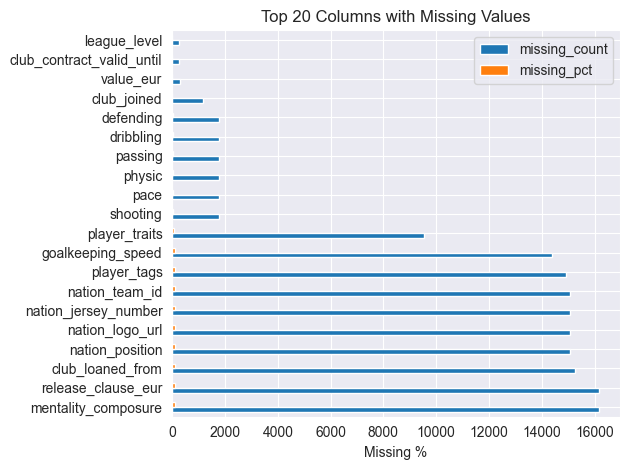

In [121]:
plt.figure(figsize=(10,6))
missing_df.head(20).plot(kind="barh")
plt.xlabel("Missing %")
plt.title("Top 20 Columns with Missing Values")
plt.tight_layout()
plt.show()

### Step 3: Investigate the 1775 mystery

Six columns have exactly 1775 missing values: `pace, shooting, passing,
dribbling, defending, physic`. This is not random. Find out **who** these
1775 players are.

**Hint:** Filter rows where `pace` is null, then look at the
`player_positions` column with `.value_counts()`.

In [122]:
pace_null= df[df["pace"].isnull()]
pace_null["player_positions"].value_counts()
#[all of GoalKeepers have null `pace, shooting, passing,dribbling, defending, physic`]


player_positions
GK    1775
Name: count, dtype: int64

### Step 4: Confirm the goalkeeper hypothesis

If your Step 3 result shows mostly "GK", prove it with numbers:
- Count total goalkeepers in the dataset
- Compare with the number of null `pace` values
- They should match exactly

**Hint:** Use `.shape[0]` to count rows after filtering.

In [123]:
a = len(df[df["player_positions"]=="GK"])
b = (df.pace.isnull().sum())

print(f"Total GoalKeepers:{a}")
print(f"number of pace null players:{b}")
print(f"is Match: {a==b}")


Total GoalKeepers:1775
number of pace null players:1775
is Match: True


### Question 2.1: 100% Empty Columns

Which columns are completely empty (100% null)? Why might they be empty,
and is it safe to drop them?

**Think about:** This dataset is FIFA **15** (released in 2014). Some
columns might exist because the CSV format is shared across all FIFA
versions, but the feature was only added in later games.

#### My answer:
- 100% empty columns:['release_clause_eur', 'mentality_composure']
- Why they might be empty (my hypothesis): this features can not be added on this version of game
- Decision (drop / keep / something else): i will drop beaceuse ı have any value for fill

In [124]:
empty_cols = [c for c in df.columns if df[c].isnull().all()]
print(empty_cols)


['release_clause_eur', 'mentality_composure']


### Question 2.2: The 1775 Mystery — Solved

I investigated why `pace, shooting, passing, dribbling, defending, physic`
have exactly 1775 missing values.

#### My answer:
- Who are these 1775 players? : All GK
- Why don't they have these stats? : may spesificly goalkeeper they have no value on there cart like that
- What does this mean for our project (similar player recommendation)?: What does this mean for our project? Goalkeepers and outfield
  players have completely different feature sets. We should build
  TWO separate similarity pipelines: one for outfield players using
  the 6 main stats + sub-stats, one for goalkeepers using only
  goalkeeping_* features. Mixing them in one model would break
  similarity calculations.

### Question 2.3: My Strategy — Drop, Fill, or Keep

Based on the missing value analysis, here is my plan for each problematic
column.

#### My answer: ['release_clause_eur', 'mentality_composure'] DROP
club_loaned_from KEEP
nation_team_id, nation_position, nation_jersey_number, nation_logo_url KEEP
player_tags, player_traits DROP
pace, shooting, ..., physic KEEP WE MAKE ANOTHER PİPELİNE FOR GK

**Columns I will DROP (>90% null or useless):**
-['release_clause_eur', 'mentality_composure'],player_tags, player_traits DROP

**Columns I will FILL (and how):**
| Column | Fill method | Why |
|--------|-------------|-----|
|value_eur| median            |  few nulls   |
'wage_eur|   median           |   few nulls


**Columns I will KEEP as-is (null is meaningful):**
-club_loaned_from KEEP
-nation_team_id, nation_position, nation_jersey_number, nation_logo_url KEEP
-player_tags, player_traits DROP
-pace, shooting, ..., physic KEEP WE MAKE ANOTHER PİPELİNE FOR GK

In [125]:
missing_df.loc[['value_eur', 'wage_eur', 'club_position']]

,missing_count,missing_pct
value_eur,311,1.93
wage_eur,239,1.48
club_position,239,1.48


## Görev 3 — Data Type Fixes
**Süre:** ~30 dk
**Amaç:** Convert columns with wrong dtypes so we can use them in
calculations later.

### What I will do:
1. Inspect position rating columns (`ls`, `st`, ..., `gk`) — confirm "93+3" format
2. Parse them: extract the base number (93) and convert to int
3. Convert `dob` (date of birth) to datetime
4. Convert `club_joined` to datetime

### Step 1: Inspect position rating columns

Look at 3-4 position rating columns to confirm the `"93+3"` string format
and check their dtype.

**Hint:** Use `df[['ls', 'st', 'cm', 'gk']].head(5)` and `.dtypes`.

In [126]:
df[["ls","st","cm","gk"]].head(5)

,ls,st,cm,gk
0,89+3,89+3,79+3,15+3
1,91+1,91+1,77+3,16+3
2,84+3,84+3,78+3,14+3
3,87+3,87+3,76+3,17+3
4,38+3,38+3,36+3,87+3


In [127]:
(df[["ls","st","cm","gk"]].iloc[0]).dtypes

dtype('O')

### Mini investigation before Step 2

Before we parse `"93+3"`, we need to know if all values use `+`
or some use `-`. Run this:

​```python
df['ls'].str.contains('-', na=False).sum()
​```

If result > 0, some values are `"93-2"` format (subtraction!).
If result == 0, only `+` exists, parsing is simpler.

#### My finding:
[SUB CONTAİNS :     LS --> 111 /     ST --> 111   / CM -->85    /   GK --->0 ]

In [128]:
print(df["ls"].str.contains("-",na=False).sum())
print(df["st"].str.contains("-",na=False).sum())
print(df["cm"].str.contains("-",na=False).sum())
print(df["gk"].str.contains("-",na=False).sum())



111
111
85
0


### Step 2: Parse "93+3" → 93 for all 27 position rating columns

We want only the **base rating** (number before `+` or `-`).

**Strategy:**
- Use `pd.to_numeric()` with `errors='coerce'` — but first split on the operator
- A cleaner way: use regex to extract only the leading digits

**Approach 1 — string split (works if only `+`):**
​```python
df['ls'].str.split('+').str[0].astype(int)
​```

**Approach 2 — regex (works for `+` and `-`):**
​```python
df['ls'].str.extract(r'(\d+)').astype(int)
​```

**Your task:**
1. Test on ONE column first (`ls`)
2. Print the first 5 values to confirm
3. Apply to all 27 position rating columns using a `for` loop

(Yes, here a loop is fine — we want to update 27 separate columns,
this is one of the rare cases pandas needs explicit iteration.)

**Use `position_rating_cols` list from Cell 19** — already defined.

In [129]:
#df["ls"]=df["ls"].str.split(pat= "+").str[0].astype(int)
##df["ls"] = df["ls"].str.split(pat = "-").str[0].astype(int)
#df["ls"]
###burada yaptığım hatalı çünkü önce 1. satırda inte çevirip sonra tekrar str metdou üzerine işlem yapmaya çalıyorum bu hatalı burada iki pattern olduğu için regex şart + -
test = df["ls"].str.extract(r'(\d+)').astype(int)
print(test.head(2))
print(test.dtypes)


    0
0  89
1  91
0    int64
dtype: object


In [130]:
import pandas as pd
# Mini test
test_data = pd.Series(["93+3", "85-2", "70+0", "60", "90+5"])
print("Original:")
print(test_data)
print()
print("After extract:")
print(test_data.str.extract(r'(\d+)'))
# r"(\d+)" burada r: raw string içerdeki \d+ bana birden fazla(+ile sağlandı) rakam getir demek d : rakam


Original:
0    93+3
1    85-2
2    70+0
3      60
4    90+5
dtype: object

After extract:
    0
0  93
1  85
2  70
3  60
4  90


In [131]:
import pandas as pd

ex1 = pd.Series([
    "Match 93: Liverpool vs Chelsea",
    "Year 2024 was great",
    "Flight AB123 departed at 17:45",
    "Score was 7-2 yesterday",
    "No numbers here"
])
ex1 = ex1.str.extract(r"(\d{2})")
print(ex1)

     0
0   93
1   20
2   12
3  NaN
4  NaN


In [132]:
ex2 = pd.Series([
    "Messi_10",
    "Ronaldo",
    "Neymar Jr",
    "Van der Berg",
    "  spaces  "
])
ex2= ex2.str.extract(r"(\w+)")
print(ex2)

          0
0  Messi_10
1   Ronaldo
2    Neymar
3       Van
4    spaces


In [133]:
ex3 = pd.Series([
    "FIFA 15",
    "hello WORLD",
    "UEFA Champions League",
    "lowercase only",
    "MessiGOAT"
])

ex3 = ex3.str.extract(r"([A-Z]+)")
print(ex3)

       0
0   FIFA
1  WORLD
2   UEFA
3    NaN
4      M


In [134]:
for x in position_rating_cols:
   df[x]= df[x].str.extract(r'(\d+)').astype(int)

In [135]:
print(df[position_rating_cols])

       ls  st  rs  lw  lf  cf  rf  rw  lam  cam  ...  ldm  cdm  rdm  rwb  lb  \
0      89  89  89  92  90  90  90  92   92   92  ...   62   62   62   62  54   
1      91  91  91  89  91  91  91  89   89   89  ...   63   63   63   63  57   
2      84  84  84  88  87  87  87  88   88   88  ...   64   64   64   64  55   
3      87  87  87  84  86  86  86  84   86   86  ...   65   65   65   61  56   
4      38  38  38  36  37  37  37  36   36   36  ...   40   40   40   36  36   
...    ..  ..  ..  ..  ..  ..  ..  ..  ...  ...  ...  ...  ...  ...  ...  ..   
16150  32  32  32  33  30  30  30  33   30   30  ...   38   38   38   37  40   
16151  41  41  41  37  39  39  39  37   37   37  ...   30   30   30   31  32   
16152  38  38  38  41  40  40  40  41   41   41  ...   37   37   37   36  34   
16153  38  38  38  38  35  35  35  38   33   33  ...   46   46   46   48  51   
16154  35  35  35  33  33  33  33  33   31   31  ...   36   36   36   37  39   

       lcb  cb  rcb  rb  gk  
0       4

In [136]:
for x in position_rating_cols:
     print( df[x])

0        89
1        91
2        84
3        87
4        38
         ..
16150    32
16151    41
16152    38
16153    38
16154    35
Name: ls, Length: 16155, dtype: int64
0        89
1        91
2        84
3        87
4        38
         ..
16150    32
16151    41
16152    38
16153    38
16154    35
Name: st, Length: 16155, dtype: int64
0        89
1        91
2        84
3        87
4        38
         ..
16150    32
16151    41
16152    38
16153    38
16154    35
Name: rs, Length: 16155, dtype: int64
0        92
1        89
2        88
3        84
4        36
         ..
16150    33
16151    37
16152    41
16153    38
16154    33
Name: lw, Length: 16155, dtype: int64
0        90
1        91
2        87
3        86
4        37
         ..
16150    30
16151    39
16152    40
16153    35
16154    33
Name: lf, Length: 16155, dtype: int64
0        90
1        91
2        87
3        86
4        37
         ..
16150    30
16151    39
16152    40
16153    35
16154    33
Name: cf, Length: 

### Verify Step 2

After the loop, check that all 27 columns are now numeric:

​```python
df[position_rating_cols].dtypes
​```

All should show `int64` or `float64`. If any show `object`, something failed.

In [137]:
df[position_rating_cols].dtypes

ls     int64
st     int64
rs     int64
lw     int64
lf     int64
cf     int64
rf     int64
rw     int64
lam    int64
cam    int64
ram    int64
lm     int64
lcm    int64
cm     int64
rcm    int64
rm     int64
lwb    int64
ldm    int64
cdm    int64
rdm    int64
rwb    int64
lb     int64
lcb    int64
cb     int64
rcb    int64
rb     int64
gk     int64
dtype: object

### Step 3: Convert `dob` to datetime

`dob` (date of birth) is currently stored as a string. Convert to proper
datetime so we can calculate ages or "days since signing" later.

**Hint:** `pd.to_datetime(df['dob'])` then reassign to `df['dob']`.

After conversion, verify with `df['dob'].dtype` — should show `datetime64[ns]`.

In [138]:
print(type(df["dob"][0]))
print(df["dob"][0])
print(df[["dob"]].isna().value_counts())
df["dob"]= pd.to_datetime(df["dob"])
print(type(df["dob"][0]))
print(df["dob"].dtype)





<class 'str'>
1987-06-24
dob  
False    16155
Name: count, dtype: int64
<class 'pandas._libs.tslibs.timestamps.Timestamp'>
datetime64[ns]


### Step 4: Convert `club_joined` to datetime

Same as Step 3, but for `club_joined`.

**Watch out:** Some rows might be null. Use `errors='coerce'` so invalid
values become `NaT` (Not a Time) instead of raising an error.

​```python
df['club_joined'] = pd.to_datetime(df['club_joined'], errors='coerce')
​```

Verify dtype after conversion.

In [139]:
print(df["club_joined"].dtype)
df["club_joined"] = pd.to_datetime(df["club_joined"])
print(df["club_joined"].dtype)

object
datetime64[ns]


### Question 3.1: The position rating format

What is the meaning of the `+3` part in `"93+3"`? Why does FIFA store
position ratings this way? For our similarity project, should we use
the base rating, the total (96), or both?

#### My answer:
- Meaning of `+3`: "+" or "-" came from players chemsitry with other players
- Why FIFA stores it this way: its a futre from ultimateteam mode on fifa this mode based on chemistry
- My choice for the project (base / total / both) and why: base

### Question 3.2: My data type fixes summary

| Column(s) | Old Type | New Type | Method | Why |
|-----------|----------|----------|--------|-----|
| dob | object | datetime64 | `pd.to_datetime()` | To calculate ages |
| club_joined | object | datetime64 | pd.to_datetime() | to calculate loan |
| ls, st, ..., gk (27 cols) | object | int  | str.extract() | use on our model correctly |

## 🏁 Day 1 Closing Note

### What I did today:
- Loaded FIFA 15 dataset (16,155 rows × 110 cols), categorized all
  columns into 10 logical groups (identity, stats, positions, etc.)
- Performed missing value analysis — found that release_clause_eur and
  mentality_composure are 100% null (features added in later FIFA versions)
- Discovered that exactly 1775 missing values in pace/shooting/passing/etc.
  all belong to goalkeepers — a critical insight that will shape our
  modeling pipeline (2 separate models for GK vs outfield players)
- Fixed data types: parsed "93+3" position ratings to integers using
  regex, converted dob and club_joined to datetime

### What I learned (key concepts):
- Pandas `.str` accessor: bridge between Python string methods and Series
- Regex basics: `\d+`, capture groups `()`, raw strings `r''`
- Difference between `.count()` (counts non-null) vs `.isnull().sum()`
  (counts null) — .count() fooled me at first
- When to loop vs when to vectorize: 27 columns with different names
  need a loop, but within each column, pandas is vectorized
- Defensive coding: `errors='coerce'` for robust datetime conversion

### Where I struggled the most:
- Understanding regex — specifically what `r''` means and why we need
  parentheses `()` for capture groups in `.str.extract()`
- Initially I tried `.str.split('+')` then `.str.split('-')` sequentially,
  but after first line the column became int, so second line crashed.
  Lesson: chain transformations don't work when intermediate types change.
### Ready for Day 2:
- [ x] Notebook saved
- [ x] All cells run without errors
- [x ] Sent "Day 1 done" to mentor

# 📅 Day 2 — Deep Analysis
**Goal:** Understand how the data behaves. Find patterns, distributions,
and relationships between features. Every chart needs a 1-sentence comment.

**Tasks today:**
- Task 4: Position Analysis (most important)
- Task 5: Distribution Analysis
- Task 6: Age vs Potential
- Task 7: Correlation Matrix

## Task 4 — Position Analysis
**Time:** ~50 min
**Why this matters:** Our project recommends similar players FOR A POSITION.
If we don't understand positions, we can't filter or group players correctly.

### Step 1: How is `player_positions` stored?

Look at the first 10 values. Is it a single value like `"ST"` or
multiple values like `"ST, CF"`? Check with `.value_counts()` too —
how many unique combinations exist?

In [140]:
df["player_positions"].value_counts().sort_values(ascending=False)

player_positions
CB                 1853
GK                 1775
ST                 1677
CM                  806
LB                  623
                   ... 
RM, RW, ST, RB        1
RB, RW, RM            1
LB, CB, LWB           1
CDM, RB, CB, CM       1
CM, ST, LM            1
Name: count, Length: 907, dtype: int64

### Step 2: How many players have multiple positions?

Count how many players have a comma in their `player_positions` value.

**Hint:** `.str.contains(',')` returns True/False for each row.
Then `.sum()` counts the Trues.

#### My answer:
- Players with 1 position: 10243
- Players with 2+ positions: 5231
- What percentage has multiple positions: 46%

In [141]:
one_positions = (~( df["player_positions"].str.count(",").sum()))
print(one_positions)
total = print(df["player_positions"].str.contains(",").sum())
three_positions=print((df["player_positions"].str.count(",")==2).sum())
two_positions = print((df["player_positions"].str.count(",")==1).sum())
four_positions = print((df["player_positions"].str.count(",")==3).sum())



-10243
7501
1799
5231
471


In [142]:
multiple_prc = (df["player_positions"].str.contains(",").sum())/ df["player_positions"].count()
multiple_prc = multiple_prc*100
print(multiple_prc)

46.431445372949554


### Step 3: Extract the PRIMARY position

For our project, each player needs ONE main position. The first position
in the list is usually the primary one.

Create a new column called `main_position`:

**Hint:** `.str.split(', ').str[0]` — split by comma+space, take first element.

After creating it, check: `df['main_position'].nunique()` — how many
unique positions exist?

In [143]:
df["main_position"]=df["player_positions"].str.split(", ").str[0]
#split cf,cdm,fd yi liste çevirir [ "cf","cdm","fd"] .str ile ilk elemanını alır

In [144]:
df["main_position"].nunique()

15

### Step 4: Position frequency bar chart

Make a bar chart showing how many players play each position
(using `main_position`).

**Hint:** `df['main_position'].value_counts()` gives you the data.
Then `.plot(kind='bar')` or use `plt.bar()`.

Add title, labels, and `figsize=(12,5)` so all position names are readable.

#### My observation (1 sentence):
[CB ,ST most popular ones/ LWB AND RWB Are rare  ]

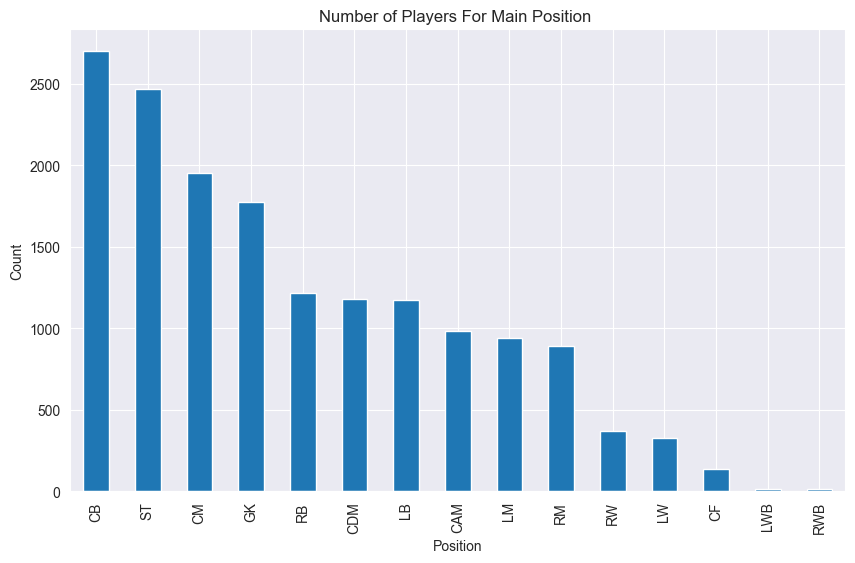

In [145]:
plt.figure(figsize=(10,6))
df["main_position"].value_counts().plot(kind="bar")
plt.title("Number of Players For Main Position ")
plt.xlabel("Position")
plt.ylabel("Count")
plt.show()

**### Step 5: Group positions into 4 categories

Create a new column `position_group` with 4 values:
- **Forward:** ST, CF, LW, RW, LF, RF
- **Midfielder:** _CAM, CM, CDM, LM, RM, LAM, RAM, LCM, RCM, LDM, RDM_
- **Defender:** CB, LB, RB, LWB, RWB, LCB, RCB
- **Goalkeeper:** GK

**Approach:** Write a function that takes a position string and returns
the group. Then use `.map()` or `.apply()` on `main_position`.


In [146]:
def get_position_group(pos):
    forwards =  ["ST", "CF", "LW", "RW", "LF", "RF"]
    midfielders = ["CAM", "CM", "CDM", "LM", "RM", "LAM", "RAM", "LCM", "RCM", "LDM", "RDM"]
    defenders = ["CB", "LB", "RB", "LWB", "RWB", "LCB", "RCB"]
    goalkeepers = ["GK"]
    if pos in forwards:
        return "Forward"
    elif pos in midfielders:
        return "Midfielder"
    elif pos in defenders:
         return "Defender"
    elif pos in goalkeepers:
        return "Goalkeeper"
    else:
        return "Unknown"


In [147]:
df["position_group"]= df["main_position"].apply(get_position_group)

In [148]:
df["position_group"].value_counts().sort_values(ascending=False)

position_group
Midfielder    5952
Defender      5123
Forward       3305
Goalkeeper    1775
Name: count, dtype: int64

### Step 6: Position group bar chart

Make a bar chart of `position_group` value counts.
This should show 4 bars: Forward, Midfielder, Defender, Goalkeeper.

#### My answer:
| Group | Count |
|-------|-------|
| Forward | ? |
| Midfielder | ? |
| Defender | ? |
| Goalkeeper | ? |
| **Total** | **16155** |

<Axes: xlabel='position_group'>

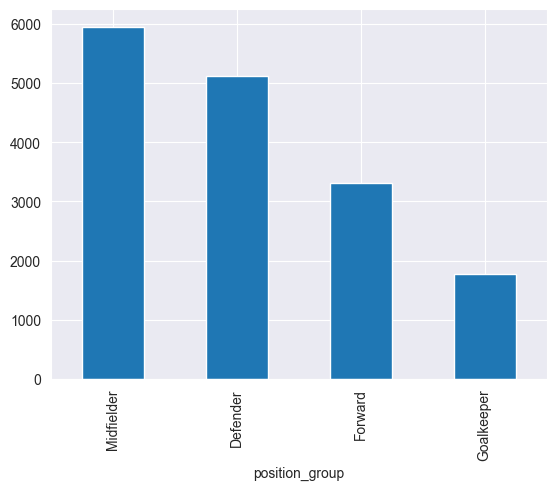

In [149]:
df["position_group"].value_counts().plot(kind="bar")

In [150]:
df["position_group"].value_counts()

position_group
Midfielder    5952
Defender      5123
Forward       3305
Goalkeeper    1775
Name: count, dtype: int64

### Question 4.1: Position decisions for our model

Now that you understand positions, answer these:

- Should we compare a ST (striker) with a CB (center back)? Why or why not?
- How will you use `main_position` in similarity calculation — as a
  **filter** (only compare same position) or as a **feature** (include
  in distance calculation)?
- What about players who can play multiple positions (e.g. "CM, CAM, CDM")?
  Are they more "similar" to more players?

#### My answer:
[-Should we compare a ST (striker) with a CB (center back)? Why or why not?
- No because every positions have indivuduals rating like defenders pys is have big difference if u compare with any wingers
- -ı will use "main_positon" as a future because a team looking for firs positon of player
- idk]


## Task 5 — Distribution Analysis
**Time:** ~30 min
**Why this matters:** If we don't know how our features are distributed,
we can't choose the right scaler or similarity metric later.

### Step 1: Histogram grid for key variables

Create a 2×3 subplot grid with histograms for:
`overall`, `potential`, `value_eur`, `wage_eur`, `age`, and
`growth` (= potential - overall, create this column first).

**Hints:**
- First create growth: `df['growth'] = df['potential'] - df['overall']`
- `fig, axes = plt.subplots(2, 3, figsize=(15, 8))` creates the grid
- `axes[0,0]` is top-left, `axes[1,2]` is bottom-right
- Use `df['column'].hist(ax=axes[row, col], bins=30)`
- Add `axes[row, col].set_title('Column Name')` for each

#### My observation for each:
- overall: [normal? skewed?]
- potential: [similar to overall?]
- value_eur: [skewed? how much?]
- wage_eur: [similar to value?]
- age: [what shape?]
- growth: [what does it tell us?]

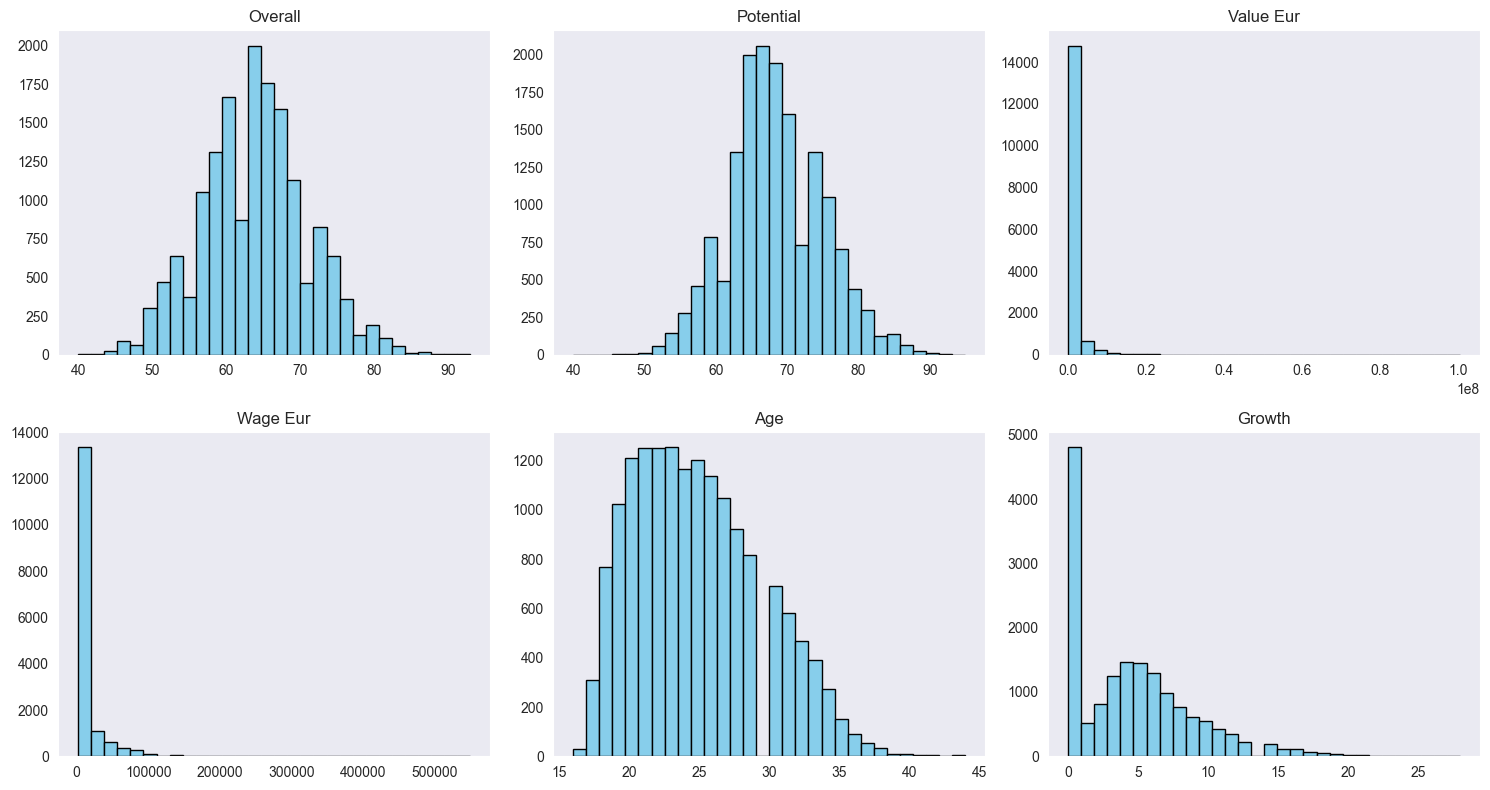

In [151]:


# 1. Create the growth column
df['growth'] = df['potential'] - df['overall']

# 2. Define the columns to plot
cols = ["overall", "potential", "value_eur", "wage_eur", "age", "growth"]

# 3. Create the 2x3 grid
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# 4. Flatten the axes for easy iteration
axes_flat = axes.flatten()

# 5. Loop through columns and axes to plot
for i, col in enumerate(cols):
    df[col].hist(ax=axes_flat[i], bins=30, color='skyblue', edgecolor='black')
    axes_flat[i].set_title(col.replace('_', ' ').title())
    axes_flat[i].grid(False) # Optional: cleans up the background

# Adjust layout so titles don't overlap
plt.tight_layout()
plt.show()

### Step 2: Log transform for `value_eur`

`value_eur` is probably extremely right-skewed (few expensive players,
many cheap ones). Apply log transform and compare.

**Steps:**
1. Create: `df['log_value'] = np.log1p(df['value_eur'])`
   (use `np.log1p` not `np.log` — log1p handles zero values safely)
2. Plot two histograms side by side: original vs log-transformed
3. Don't forget `import numpy as np`

#### My answer:
- Did the log transform make the distribution more normal?
- Why does this matter for our similarity model?

In [152]:
import numpy as np
df["log_value"]= np.log1p(df["value_eur"])

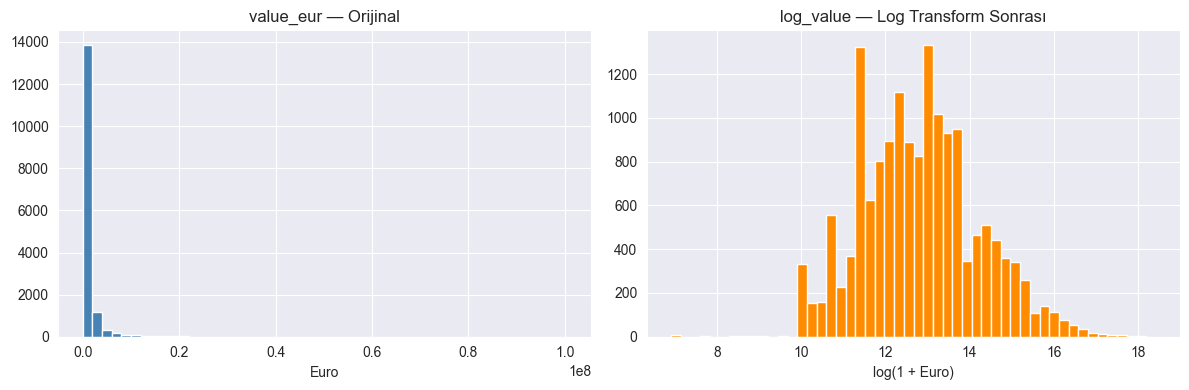

In [153]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Sol: orijinal dağılım
axes[0].hist(df['value_eur'], bins=50, color='steelblue')
axes[0].set_title('value_eur — Orijinal')
axes[0].set_xlabel('Euro')

# Sağ: log transform sonrası
axes[1].hist(df['log_value'], bins=50, color='darkorange')
axes[1].set_title('log_value — Log Transform Sonrası')
axes[1].set_xlabel('log(1 + Euro)')

plt.tight_layout()
plt.show()


### Step 3: Overall vs Value scatter plot

Create a scatter plot: x = overall, y = value_eur.

**Hints:**
- `plt.scatter(df['overall'], df['value_eur'], alpha=0.3, s=5)`
- `alpha=0.3` makes dots transparent (so you can see density)
- `s=5` makes dots small

#### My observation:
[about 80 rating there is a exponantial incrase begining]

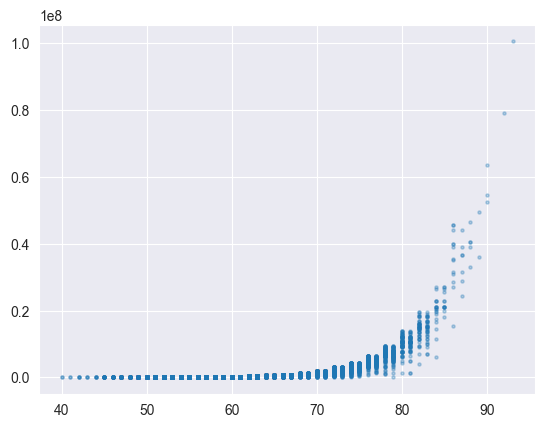

In [154]:
plt.scatter(df["overall"], df["value_eur"],s=5,alpha=0.3)

### Question 5.1: What did the distributions teach you?

- Which variable needs log transform before using in a model? Why?
- Is `overall` normally distributed? Why does this matter?
- If `value_eur` is exponential, what does that mean for finding
  "similar" players by value?

#### My answer:
[ -Which variable needs log transform before using in a model? Why?
  Growth ,wage_eur,value_eur need o be log transform cause thera are skewed
  - Is `overall` normally distributed? Why does this matter?
    - yes idk
        - If `value_eur` is exponential, what does that mean for finding
  "similar" players by value?
for finding high rating player need to be high budget]

## Task 6 — Age vs Potential
**Time:** ~35 min
**Why this matters:** Clubs don't just want similar players — they want
similar players WITH GROWTH POTENTIAL. Understanding age-potential
relationship is football domain knowledge that impresses interviewers.

### Step 1: Scatter plot — Age vs Overall

Create a scatter plot: x = age, y = overall.
Use `alpha=0.3, s=5` for transparency and small dots.
Add title, xlabel, ylabel.

#### My observation:
[25-30 age is peak age for player after 30 rating is decline]

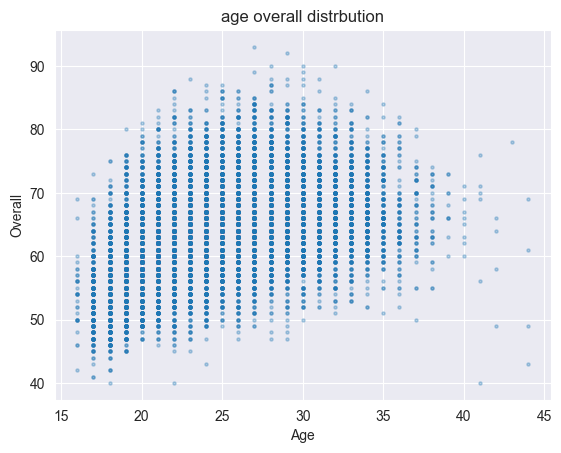

In [155]:
df.plot(kind="scatter",x="age",y="overall",s=5,alpha=0.3)
plt.xlabel("Age")
plt.ylabel("Overall")
plt.title("age overall distrbution")
plt.show()


### Step 2: Scatter plot — Age vs Growth

You already created `growth = potential - overall`.
Make a scatter plot: x = age, y = growth.

#### My observation:
[At what age does growth drop to 0? What does growth=0 mean
in football terms? — it means the player has reached his maximum
potential and will not improve anymore]

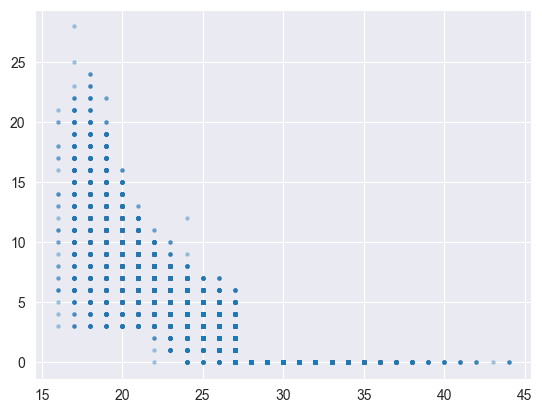

In [156]:
plt.scatter(x=df["age"], y=df["growth"],s=5,alpha=0.3)

### Step 3: Average overall by age (line chart)

Instead of a scatter plot (too noisy), calculate the **mean overall
for each age** and plot it as a line.

**Hint:** `df.groupby('age')['overall'].mean()` gives you a Series
with age as index and mean overall as values. Then `.plot(kind='line')`.

#### My observation:
[What is the peak age? Does the line go up, peak, then decline?]

<Axes: xlabel='age'>

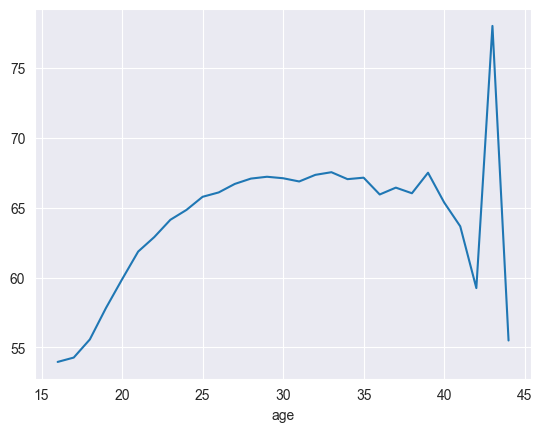

In [157]:
df.groupby("age")["overall"].mean().plot(kind="line")

### Question 6.1: Football domain knowledge

Based on your 3 charts, answer like a football analyst:

- What is the **peak age range** for football players?
- At what age should clubs **sell** a player before decline starts?
- If a club wants a **young replacement** (under 23) with high growth,
  what minimum `potential` should they look for?
- How would you use `age` and `growth` in our similarity model?

#### My answer:
[ What is the **peak age range** for football players?
-25 - 30
 - At what age should clubs **sell** a player before decline starts?
  - after 30
    - If a club wants a **young replacement** (under 23) with high growth,
  what minimum `potential` should they look for?
      - idk
            - How would you use `age` and `growth` in our similarity model?
                  - idk]

## Task 7 — Correlation Matrix
**Time:** ~25 min
**Why this matters:** If two features are highly correlated (e.g. 0.95),
keeping both in our model adds noise without new information. We need
to know which stats move together.

### Step 1: Filter out goalkeepers

Before computing correlations, **remove goalkeepers** from the data.
Their main stats (pace, shooting, etc.) are null and would break
the calculation.

Create: `df_outfield = df[df['main_position'] != 'GK']`

Verify: how many players remain?

In [158]:
df_outfield =df[df["main_position"] !="GK"]
len(df_outfield)

14380

### Step 2: Correlation heatmap — 6 main stats

Calculate the correlation matrix for:
`pace, shooting, passing, dribbling, defending, physic`

Then visualize with seaborn heatmap.

**Hints:**
- `import seaborn as sns`
- `corr_matrix = df_outfield[main_stats].corr()`
- `sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')`
- `annot=True` shows numbers in each cell
- `fmt='.2f'` shows 2 decimal places
- Use `figsize=(8,6)`

#### My observations:
- Highest positive correlation : passing - shooting
- Highest negative correlation : shooting - defending
- Does this make football sense? Why? yes cause ı dont see any fottball player have good defending with good shooting

<Axes: >

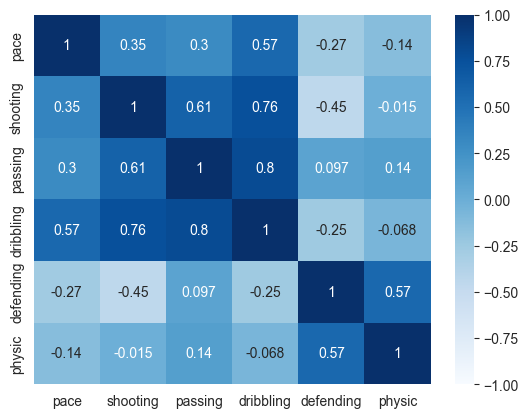

In [159]:
import seaborn as sns
figsize = (8,6)
corr_matrix = df_outfield[main_stats].corr()
sns.heatmap(corr_matrix, annot=True, cmap="Blues",center=0,vmin=-1,vmax=1)

### Step 3: Bigger correlation — all sub-stats

Now do the same but with ALL detailed sub-stats:
`attacking_*, skill_*, movement_*, power_*, mentality_*, defending_*`

**Hint:** Combine lists from Day 1:
```python
all_sub_stats = (atack_filter + skill_cols + movement_cols +
                 power_cols + mentality_cols + defend_filter)
```

Make a bigger heatmap: `figsize=(16, 12)`. Turn off `annot`
(too many numbers) and just look at the color pattern.

#### My observation:
[Are there any clusters of high correlation? Which stat groups
correlate with each other?]

In [160]:
all_sub_stats =  (atack_filter+ skill_cols + movement_cols+ power_cols + mentality_cols + defending_cols)
all_sub_stats

['attacking_crossing',
 'attacking_finishing',
 'attacking_heading_accuracy',
 'attacking_short_passing',
 'attacking_volleys',
 'skill_moves',
 'skill_dribbling',
 'skill_curve',
 'skill_fk_accuracy',
 'skill_long_passing',
 'skill_ball_control',
 'movement_acceleration',
 'movement_sprint_speed',
 'movement_agility',
 'movement_reactions',
 'movement_balance',
 'power_shot_power',
 'power_jumping',
 'power_stamina',
 'power_strength',
 'power_long_shots',
 'mentality_aggression',
 'mentality_interceptions',
 'mentality_positioning',
 'mentality_vision',
 'mentality_penalties',
 'mentality_composure',
 'defending_marking_awareness',
 'defending_standing_tackle',
 'defending_sliding_tackle']

<Axes: >

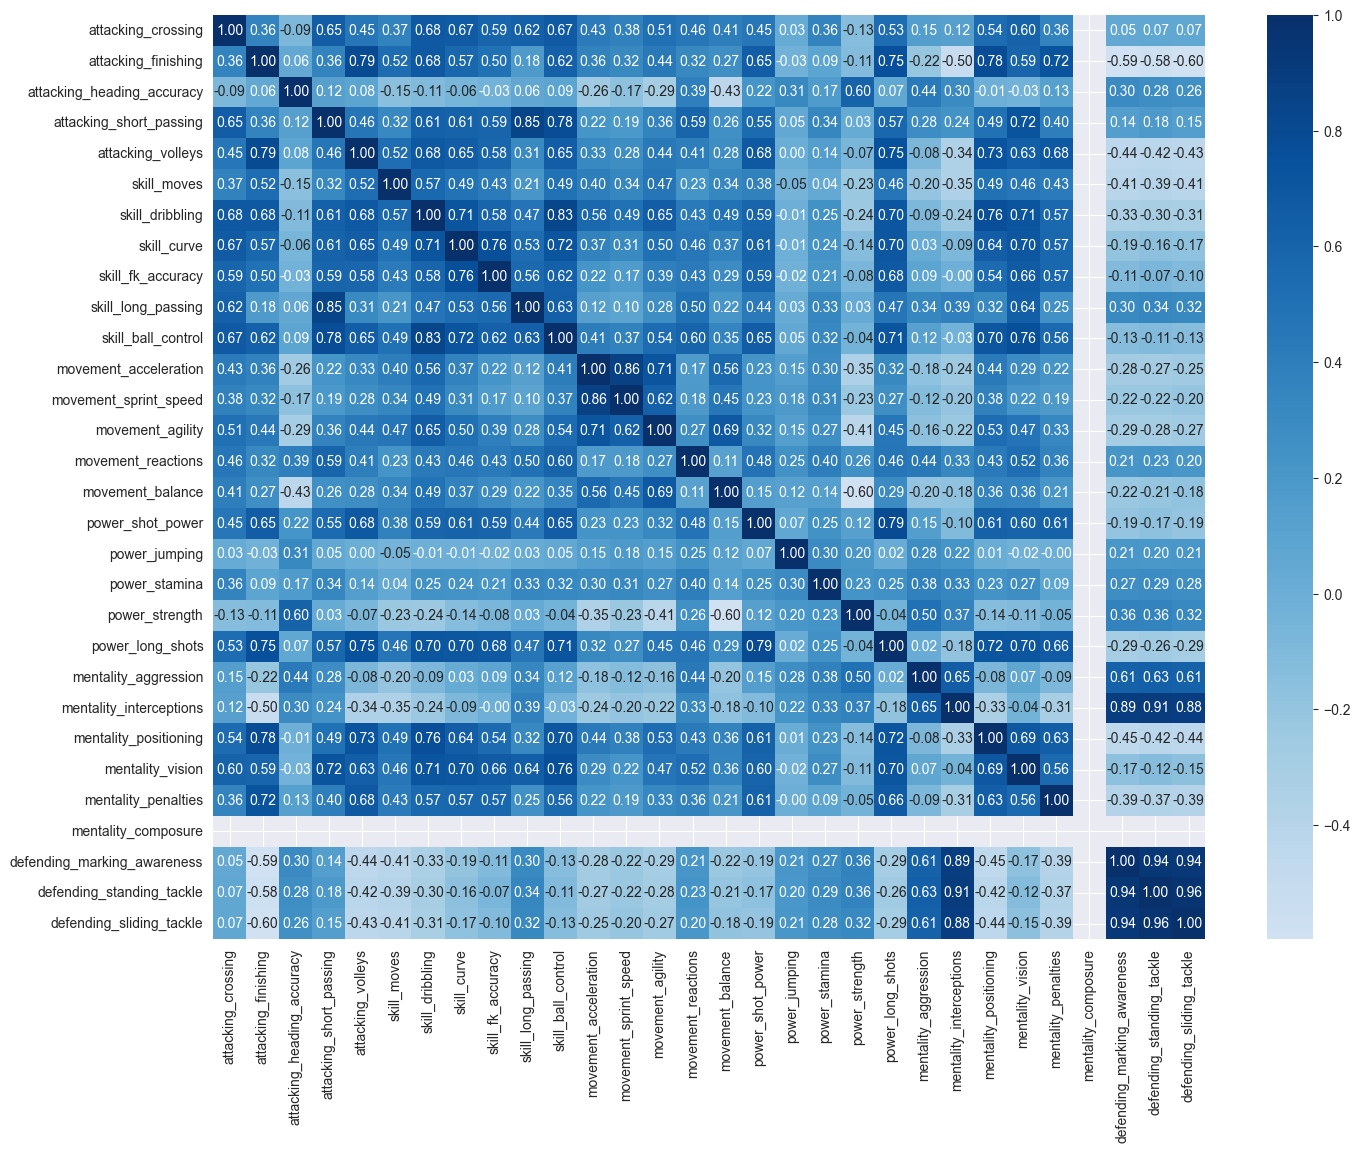

In [161]:

corr_matrix = df_outfield[all_sub_stats].corr()
plt.figure(figsize=(16,12))
sns.heatmap(corr_matrix, annot=(True), cmap="Blues",center=0,fmt=".2f")


### Question 7.1: What do correlations mean for our model?

- If `shooting` and `attacking_finishing` have 0.9 correlation, should
  we keep both in the similarity model? What is the risk?
- Name 2 stats that are probably NOT correlated. Why?
- Would you use the 6 main stats or the 30+ sub-stats for similarity
  calculation? What is the trade-off?

#### My answer:
[beeing high corelation with each other is can be cauese off mullticolenaitry and its harmful for our model
mentality_penalites defeneding_tackele are not correlated cause they are two different ways
 idk]

### What I did today:
- Analyzed player positions: 46% of players have multiple positions,
  extracted primary position, grouped into 4 categories
- Built distribution charts: found value_eur is extremely right-skewed,
  needs log transform
- Discovered peak age is 25-30, growth drops to 0 around age 28-30
- Created correlation heatmaps for 6 main stats and 30 sub-stats

### Key findings (things that will affect modeling):
1. Position must be used as FILTER, not feature — don't compare ST with CB
2. value_eur needs log transform before similarity calculation
3. shooting and defending are negatively correlated — makes football sense

### Most interesting discovery:
- The exponential jump in player value around 80+ overall rating

# 📅 Day 3 — Insights & Modeling Decisions
**Goal:** Validate the data makes sense, explore leagues/countries,
and make final decisions about how to build the similarity model.

**Tasks today:**
- Task 8: Sanity Check (is the data trustworthy?)
- Task 9: League & Country Analysis
- Task 10: Final Modeling Decisions (most important — no code, just thinking)

### Step 1: Top 10 players by overall rating

Show the top 10 players sorted by `overall` descending.
Display columns: `short_name`, `overall`, `potential`, `main_position`, `club_name`.

**Hint:** `df.nlargest(10, 'overall')[['short_name', 'overall', ...]]`

#### My check:
- Is Messi or Ronaldo #1? (FIFA 15 → Messi should be #1) messi is the first place
- Do the ratings look realistic? yes there is top10 football players in 2015

In [162]:
df.nlargest(10,"overall")[["short_name", "overall", "potential", "main_position", "club_name"]]

,short_name,overall,potential,main_position,club_name
0,L. Messi,93,95,CF,FC Barcelona
1,Cristiano Ronaldo,92,92,LW,Real Madrid CF
2,A. Robben,90,90,RM,FC Bayern München
3,Z. Ibrahimović,90,90,ST,Paris Saint-Germain
4,M. Neuer,90,90,GK,FC Bayern München
5,Iniesta,89,89,CM,FC Barcelona
6,L. Suárez,89,91,ST,FC Barcelona
7,R. van Persie,88,88,ST,Manchester United
8,B. Schweinsteiger,88,88,CM,FC Bayern München
9,F. Ribéry,88,88,LM,FC Bayern München


### Step 2: Top 10 most valuable players

Sort by `value_eur` descending, same columns as Step 1.

#### My check:
- Are the most valuable players also the highest rated? yes
- Any surprises? no messi defending his place

In [163]:
df.sort_values(by="value_eur",ascending=False)[["short_name", "overall", "potential", "main_position", "club_name"]]

,short_name,overall,potential,main_position,club_name
0,L. Messi,93,95,CF,FC Barcelona
1,Cristiano Ronaldo,92,92,LW,Real Madrid CF
4,M. Neuer,90,90,GK,FC Bayern München
2,A. Robben,90,90,RM,FC Bayern München
3,Z. Ibrahimović,90,90,ST,Paris Saint-Germain
...,...,...,...,...,...
15200,R. Lamare,52,55,CM,NaN
15452,J. Stevens,52,56,RM,NaN
15534,D. Bejarano,51,54,RB,NaN
15806,A. Singh,50,54,GK,NaN


### Step 3: Top 10 highest paid players

Sort by `wage_eur` descending.

#### My check:
- Do wages match with overall and value? yes
- Are there any overpaid players (high wage but low overall)? no all of this players best in the world

In [164]:
df.sort_values(by="wage_eur",ascending=False)[["short_name", "overall", "potential", "main_position", "club_name"]]

,short_name,overall,potential,main_position,club_name
0,L. Messi,93,95,CF,FC Barcelona
1,Cristiano Ronaldo,92,92,LW,Real Madrid CF
4,M. Neuer,90,90,GK,FC Bayern München
6,L. Suárez,89,91,ST,FC Barcelona
2,A. Robben,90,90,RM,FC Bayern München
...,...,...,...,...,...
15073,R. Quiñonez,53,61,GK,NaN
15200,R. Lamare,52,55,CM,NaN
15452,J. Stevens,52,56,RM,NaN
15534,D. Bejarano,51,54,RB,NaN


### Step 4: Young talents — under 21 with potential 85+

Filter: `age <= 21` AND `potential >= 85`.
Sort by `potential` descending.

Show: `short_name`, `age`, `overall`, `potential`, `growth`, `main_position`, `club_name`.

#### My check:
- Do you recognize these names? (FIFA 15 wonderkids were:
  Pogba, Götze, Neymar, Hazard if young enough, Varane, etc.)
- How big is the gap between their overall and potential?

In [165]:
df[(df["age"]<21 )& (df["potential"]>=85)][["short_name", "age", "overall", "potential", "growth", "main_position", "club_name"]]

,short_name,age,overall,potential,growth,main_position,club_name
207,A. Laporte,20,81,88,7,CB,Athletic Club de Bilbao
285,J. Draxler,20,80,85,5,LM,FC Schalke 04
286,R. Sterling,19,80,86,6,RW,Liverpool
395,Paco Alcácer,20,79,85,6,ST,Valencia CF
512,A. Oxlade-Chamberlain,20,78,86,8,RM,Arsenal
514,R. Barkley,20,78,86,8,CAM,Everton
518,M. Depay,20,78,88,10,LW,PSV
523,Marquinhos,20,78,86,8,CB,Paris Saint-Germain
526,L. Marković,20,78,87,9,RM,Liverpool
672,M. Ginter,20,77,85,8,CB,Borussia Dortmund


### Step 5: Veterans — age 35+ with overall 80+

Filter: `age >= 35` AND `overall >= 80`.

#### My check:
- Who are they? (Expect legends like Pirlo, Buffon, Totti)
- How many are there? (Should be very few — most players decline by 35)

In [166]:
(df[(df["age"]>35) & (df["overall"]>=80)])

,sofifa_id,player_url,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,...,gk,player_face_url,club_logo_url,club_flag_url,nation_logo_url,nation_flag_url,main_position,position_group,growth,log_value
101,1179,https://sofifa.com/player/1179/gianluigi-buffo...,G. Buffon,Gianluigi Buffon,GK,82,82,7000000.0,110000.0,36,...,80,https://cdn.sofifa.net/players/001/179/15_120.png,https://cdn.sofifa.net/teams/45/60.png,https://cdn.sofifa.net/flags/it.png,https://cdn.sofifa.net/teams/1343/60.png,https://cdn.sofifa.net/flags/it.png,GK,Goalkeeper,0,15.761421
153,11141,https://sofifa.com/player/11141/miroslav-klose...,M. Klose,Miroslav Klose,ST,81,81,1300000.0,80000.0,36,...,13,https://cdn.sofifa.net/players/011/141/15_120.png,https://cdn.sofifa.net/teams/46/60.png,https://cdn.sofifa.net/flags/it.png,NaN,https://cdn.sofifa.net/flags/de.png,ST,Forward,0,14.077876
156,31432,https://sofifa.com/player/31432/didier-drogba/...,D. Drogba,Didier Yves Drogba Tébily,ST,81,81,1300000.0,90000.0,36,...,14,https://cdn.sofifa.net/players/031/432/15_120.png,https://cdn.sofifa.net/teams/5/60.png,https://cdn.sofifa.net/flags/gb-eng.png,NaN,https://cdn.sofifa.net/flags/ci.png,ST,Forward,0,14.077876
208,1238,https://sofifa.com/player/1238/francesco-totti...,F. Totti,Francesco Totti,"CF, ST",80,80,1200000.0,70000.0,37,...,14,https://cdn.sofifa.net/players/001/238/15_120.png,https://cdn.sofifa.net/teams/52/60.png,https://cdn.sofifa.net/flags/it.png,NaN,https://cdn.sofifa.net/flags/it.png,CF,Forward,0,13.997833


### Question 8.1: Data validation summary

After 5 sanity checks, is this data trustworthy?

#### My answer:
- Did all checks pass? Any anomalies? i didnt see anything anomalies
- Confidence level (high / medium / low) that this data is correct: med
- Any player that seemed wrong or surprising: only 4 legend veteran in fifa 15 its suprize me

## Task 9 — League & Country Analysis
**Time:** ~30 min
**Why this matters:** When a club searches for a replacement player,
they often filter by league ("find someone in La Liga") or nationality.
Understanding league/country distributions enriches your project
and your interview story.

### Step 1: Top 10 leagues by player count

Use `df['league_name'].value_counts().head(10)` and make a bar chart.

#### My observation:
[English ChampionShip]

<Figure size 1200x1000 with 0 Axes>

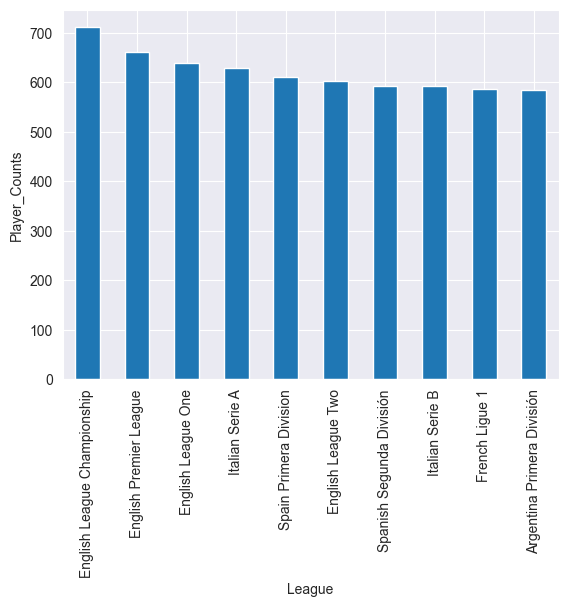

<Figure size 1200x1000 with 0 Axes>

In [167]:

df["league_name"].value_counts().head(10).plot(kind = "bar")
plt.xlabel("League")
plt.ylabel("Player_Counts")
plt.figure(figsize=(12,10))

### Step 2: Top 10 countries by player count

Use `df['nationality_name'].value_counts().head(10)` and make a bar chart.

#### My observation:
[england]

Text(0, 0.5, 'Player_Counts')

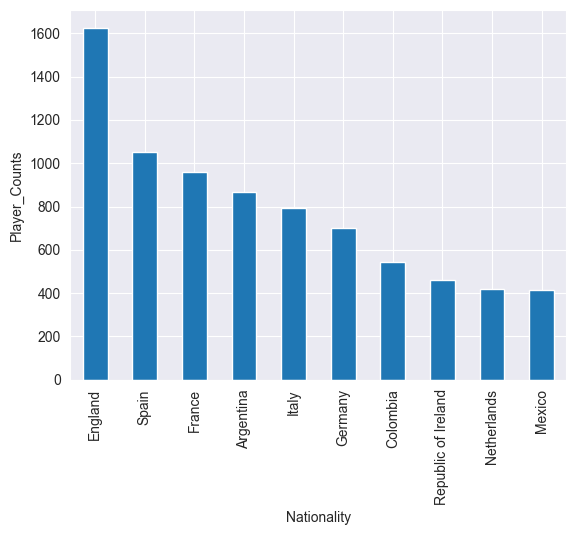

In [168]:
df["nationality_name"].value_counts().head(10).plot(kind="bar")
plt.xlabel("Nationality")
plt.ylabel("Player_Counts")

### Step 3: Average overall by league (top 10 leagues only)

This is a quality comparison: which league has the highest average
player rating?

**Hint:**
1. Find top 10 leagues: `top_leagues = df['league_name'].value_counts().head(10).index`
2. Filter: `df_top = df[df['league_name'].isin(top_leagues)]`
3. Group: `df_top.groupby('league_name')['overall'].mean().sort_values(ascending=False)`
4. Plot as horizontal bar chart

#### My observation:
[spain have best players cause they have ronaldo and meeeeeesssii lmo ]

<Axes: xlabel='league_name'>

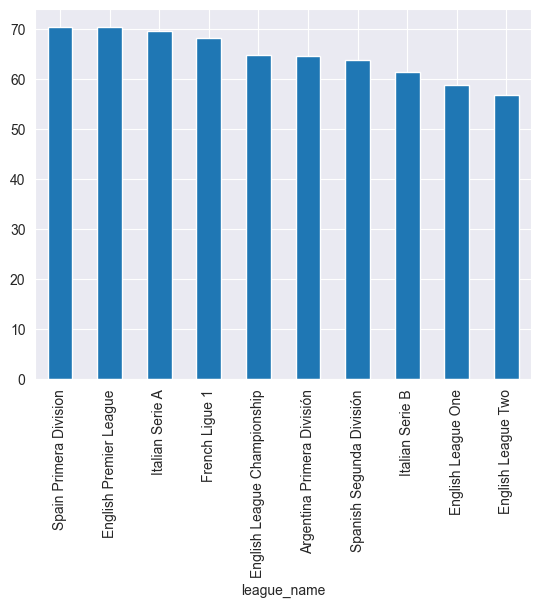

In [169]:
top_leagues = df["league_name"].value_counts().head(10).index
df_top = df[df["league_name"].isin(top_leagues)]
df_top.groupby("league_name")["overall"].agg("mean").sort_values(ascending=False).plot(kind="bar")


### Step 4: Average overall by country (top 10 countries)

Same as Step 3 but for `nationality_name`.

#### My observation:
[angentina , spain , netherlands]

<Axes: xlabel='nationality_name'>

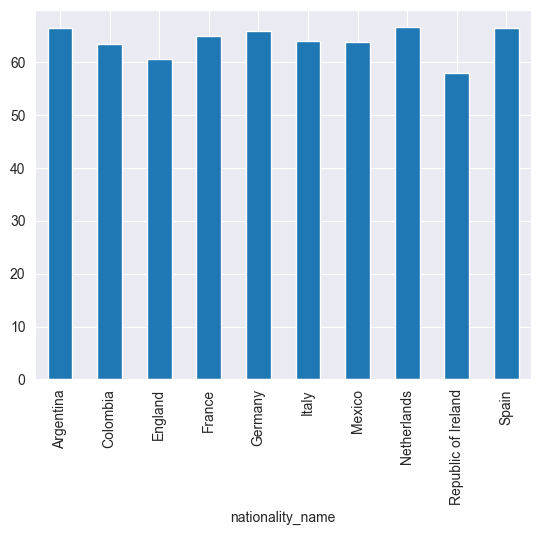

In [170]:
top_nation = df["nationality_name"].value_counts().head(10).index
df_top_nation = df[df["nationality_name"].isin(top_nation)]
df_top_nation.groupby("nationality_name")["overall"].agg("mean").plot(kind="bar")


### Question 9.1: How would league/country be useful in our project?

- Should we include `league_name` as a filter in our recommendation system? Why?
- If a Turkish club (like Galatasaray) wants a replacement, should the model
  only search in Süper Lig or all leagues?
- Would you include `nationality_name` in similarity calculation? Why or why not?

#### My answer:
[write 3-4 sentences]

## Task 10 — Final Modeling Decisions
**Time:** ~45 min
**Why this matters:** This is the MOST IMPORTANT task of the entire EDA.
No code here — only thinking and writing. Every decision you write will
directly shape your model in the next phase.

An interviewer will ask: "Walk me through your modeling decisions."
Your answer comes from this document.

### Decision 1: Feature Selection

Which columns will you use for similarity calculation?
Which will you drop? Be specific.

#### My answer:

**Features I WILL use for outfield player similarity:**
- [ main and sub stats age value_eur]

**Features I will NOT use (and why):**
- [URLs, IDs — obvious]
- [URL ID ,dob,jersey numbers real face cause unnecasseaearly for model ]

**Open question for modeling phase:**
- [anything you're unsure about?]

In [171]:
df

,sofifa_id,player_url,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,...,gk,player_face_url,club_logo_url,club_flag_url,nation_logo_url,nation_flag_url,main_position,position_group,growth,log_value
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,CF,93,95,100500000.0,550000.0,27,...,15,https://cdn.sofifa.net/players/158/023/15_120.png,https://cdn.sofifa.net/teams/241/60.png,https://cdn.sofifa.net/flags/es.png,https://cdn.sofifa.net/teams/1369/60.png,https://cdn.sofifa.net/flags/ar.png,CF,Forward,2,18.425668
1,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,"LW, LM",92,92,79000000.0,375000.0,29,...,16,https://cdn.sofifa.net/players/020/801/15_120.png,https://cdn.sofifa.net/teams/243/60.png,https://cdn.sofifa.net/flags/es.png,https://cdn.sofifa.net/teams/1354/60.png,https://cdn.sofifa.net/flags/pt.png,LW,Forward,0,18.184958
2,9014,https://sofifa.com/player/9014/arjen-robben/15...,A. Robben,Arjen Robben,"RM, LM, RW",90,90,54500000.0,275000.0,30,...,14,https://cdn.sofifa.net/players/009/014/15_120.png,https://cdn.sofifa.net/teams/21/60.png,https://cdn.sofifa.net/flags/de.png,https://cdn.sofifa.net/teams/105035/60.png,https://cdn.sofifa.net/flags/nl.png,RM,Midfielder,0,17.813711
3,41236,https://sofifa.com/player/41236/zlatan-ibrahim...,Z. Ibrahimović,Zlatan Ibrahimović,ST,90,90,52500000.0,275000.0,32,...,17,https://cdn.sofifa.net/players/041/236/15_120.png,https://cdn.sofifa.net/teams/73/60.png,https://cdn.sofifa.net/flags/fr.png,https://cdn.sofifa.net/teams/1363/60.png,https://cdn.sofifa.net/flags/se.png,ST,Forward,0,17.776324
4,167495,https://sofifa.com/player/167495/manuel-neuer/...,M. Neuer,Manuel Peter Neuer,GK,90,90,63500000.0,300000.0,28,...,87,https://cdn.sofifa.net/players/167/495/15_120.png,https://cdn.sofifa.net/teams/21/60.png,https://cdn.sofifa.net/flags/de.png,https://cdn.sofifa.net/teams/1337/60.png,https://cdn.sofifa.net/flags/de.png,GK,Goalkeeper,0,17.966550
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16150,220806,https://sofifa.com/player/220806/ellis-redman/...,E. Redman,Ellis Redman,CB,41,61,20000.0,2000.0,17,...,10,https://cdn.sofifa.net/players/220/806/15_120.png,https://cdn.sofifa.net/teams/112254/60.png,https://cdn.sofifa.net/flags/gb-eng.png,NaN,https://cdn.sofifa.net/flags/gb-wls.png,CB,Defender,20,9.903538
16151,225509,https://sofifa.com/player/225509/aaron-collins...,A. Collins,Aaron Graham John Collins,ST,41,50,30000.0,2000.0,17,...,14,https://cdn.sofifa.net/players/225/509/15_120.png,https://cdn.sofifa.net/teams/112254/60.png,https://cdn.sofifa.net/flags/gb-eng.png,NaN,https://cdn.sofifa.net/flags/gb-wls.png,ST,Forward,9,10.308986
16152,201197,https://sofifa.com/player/201197/paul-tisdale/...,P. Tisdale,Paul Tisdale,"CM, CAM",40,40,NaN,2000.0,41,...,10,https://cdn.sofifa.net/players/201/197/15_120.png,https://cdn.sofifa.net/teams/143/60.png,https://cdn.sofifa.net/flags/gb-eng.png,NaN,https://cdn.sofifa.net/flags/mt.png,CM,Midfielder,0,NaN
16153,217591,https://sofifa.com/player/217591/piotr-zemlo/1...,P. Żemło,Piotr Żemło,"LM, LB",40,50,15000.0,2000.0,18,...,12,https://cdn.sofifa.net/players/217/591/15_120.png,https://cdn.sofifa.net/teams/1873/60.png,https://cdn.sofifa.net/flags/pl.png,NaN,https://cdn.sofifa.net/flags/pl.png,LM,Midfielder,10,9.615872


### Decision 2: Goalkeeper Strategy

Goalkeepers have completely different stats. How will you handle them?

#### My answer:
- Separate pipeline or same model: Separate pipline cause GK have unique ability
- Which features for GK similarity? ['goalkeeping_diving',
 'goalkeeping_handling',
 'goalkeeping_kicking',
 'goalkeeping_positioning',
 'goalkeeping_reflexes',
 'goalkeeping_speed']
- How many GKs are in the dataset? Is that enough for a good model? 1775 ı thinh ıts enough for my model

In [172]:
len(df[df["main_position"]=="GK"])

1775

### Decision 4: Handling Value and Wage

`value_eur` and `wage_eur` are financial — not playing ability.

#### My answer:
- Include in similarity or use as filter only?: it will be filter
- If a club has a budget of 10M, how would you filter? under 10M is the filter
- Should you use raw value_eur or log_value? Why? log value cause raw one is skewed

### Decision 5: Scaling Strategy

Different features have different ranges (age: 16-45, pace: 0-100,
value_eur: 0-100M). We need to normalize them.

#### My answer:
- Which scaler: StandardScaler or MinMaxScaler? StandarScaler
- Why that choice? : cause minmax is highly sensitv
- Will you scale all features the same way? its depend on range

### Decision 6: Similarity Metric

How will you measure "similarity" between two players?

#### My answer: IDONT HAVE ANY THİNK ABOUT THİS

- Cosine similarity, Euclidean distance, or something else?
- Why?
- Will you weight some features more than others?

### Decision 7: What I learned from EDA — 3 surprises

List 3 things you discovered during EDA that you did NOT expect.

#### My answer:
1. premier league and english nation player counts
2. young talents
3. top highest pay players

### Decision 8: Next Steps — What I will build first

Describe your plan for the modeling phase in 5 bullet points.

#### My answer:
1. First I will  Preprocessing pipeline (sklearn Pipeline + StandardScaler)
2. Then...Cosine similarity ile ilk MVP — bir oyuncu seç, top-10 benzer bul
3. After that...Filtreler ekle (yaş, bütçe, pozisyon, lig)
4. For validation I will...Gerçek transferleri test et (Coutinho satıldı → modelim kimi önerir?)
5. For deployment I will... use streamlit Cloud

## 🏁 Day 3 Closing Note — EDA COMPLETE

### What I did today:
- find top players in each league and nation and plot all

### The 3 most important decisions I made:
1.
2.
3.

### Am I ready for modeling?
- [+ ] I know which features to use
- [ +] I know how to handle goalkeepers
- [ +] I know how to handle positions
- [ ] I know which scaler to use
- [ ] I know which similarity metric to start with
- [ ] I have a validation strategy

# 📅 Day 4 — Preprocessing Pipeline

**Goal:** Turn your EDA decisions into code. You'll use sklearn Pipeline for the first time.

**Before you start — watch this (15 min):**
- Search YouTube: "sklearn Pipeline tutorial" → watch the first Krish Naik or Keith Galli video
- Key concept to understand: what is `fit_transform` vs `transform`? Why does it matter?

**What is a Pipeline?**
A Pipeline chains multiple steps (scaling, encoding, etc.) and runs them in order.
Instead of doing each step manually, Pipeline handles the sequence automatically.
This is how real ML code is written in production.


## Step 1: Imports and Feature List

Before writing any code, read this:
https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html
(Just skim the first example — don't read everything)

**Hint:**
```python
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

main_stats = ['pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic']
```

Now create the log_value column:
```python
df['log_value'] = np.log1p(df['value_eur'])
```
**Research question:** What does `log1p` do differently than `log`?
Why do we need it when value_eur has zeros?
Search: "numpy log1p vs log"

**feature_cols** should be main_stats + ['age', 'log_value']

#### What I did:
[only choose main_stats because ı will select ı player from these featrues and ı used log_value cause value_eur was skewed and it will effect my model badly]

In [187]:
import  numpy as np
from  sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
main_stats.remove("age")
main_stats.append("log_value")




ValueError: list.remove(x): x not in list

## Step 2: Separate Goalkeepers

Goalkeepers have completely different stat profiles — pace/shooting means
nothing for a GK. Mixing them would break your similarity model.

**Hint:**
```python
df_outfield = df[df['position_group'] != ___].copy()
df_outfield = df_outfield.reset_index(drop=True)
print(f"Outfield players: {len(df_outfield)}")
```

**Research question:** Why is `reset_index(drop=True)` critical here?
What happens to your similarity function if you skip it?
(You already saw this bug in Day 7 — now you understand why)

#### What I did:
[how many outfield players, why reset_index matters]

In [185]:
df_outfield= df_outfield.reset_index(drop=True)
print(len(df_outfield))

14380


## Step 3: Build the Pipeline

Now build a simple Pipeline with just one step: StandardScaler.
Later you can add more steps — this is the power of Pipeline.

**Hint:**
```python
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

preprocessor = Pipeline([
    ('scaler', StandardScaler())
])

X = df_outfield[feature_cols].fillna(0)
X_scaled = preprocessor.fit_transform(X)

print(f"Shape: {X_scaled.shape}")
print(f"Mean of first feature (should be ~0): {X_scaled[:, 0].mean():.4f}")
print(f"Std of first feature (should be ~1): {X_scaled[:, 0].std():.4f}")
```

**Research question:** Why should mean be ~0 and std be ~1 after StandardScaler?
Search: "StandardScaler how it works"

**Why fillna(0)?** Check how many nulls your feature_cols have first:
```python
df_outfield[feature_cols].isnull().sum()
```
Is filling with 0 the right choice here? What are the alternatives?

#### What I did:
[Shape: (14380, 8)
Mean of first feature : 0.0000
Std of first feature : 1.0000
274 null value on log_value column]

In [193]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

preprocessor = Pipeline([
    ('scaler', StandardScaler())
])

feature_cols = main_stats

X = df_outfield[feature_cols].fillna(0)
X_scaled = preprocessor.fit_transform(X)

In [196]:
print(f"Shape: {X_scaled.shape}")
print(f"Mean of first feature (should be ~0): {X_scaled[:, 0].mean():.4f}")
print(f"Std of first feature (should be ~1): {X_scaled[:, 0].std():.4f}")

Shape: (14380, 8)
Mean of first feature (should be ~0): 0.0000
Std of first feature (should be ~1): 1.0000


In [197]:
df_outfield[feature_cols].isnull().sum()


pace           0
shooting       0
passing        0
dribbling      0
defending      0
physic         0
log_value    274
age            0
dtype: int64

## Step 4: Sanity Check — Does the scaling make sense?

Before moving to similarity, verify your Pipeline output is correct.

**Hint:**
```python
# Create a readable DataFrame from scaled output
df_scaled = pd.DataFrame(X_scaled, columns=feature_cols)

# Compare original vs scaled for Messi
messi_idx = df_outfield[df_outfield['short_name'] == 'L. Messi'].index[0]

print("=== ORIGINAL ===")
print(df_outfield.loc[messi_idx, feature_cols])

print("\n=== SCALED ===")
print(df_scaled.loc[messi_idx])
```

**What to look for:**
- Messi's pace is 90 in original → what is it after scaling? Is it a high positive number?
- A player with overall 50 → are their scaled values mostly negative?
- Does the scaling direction make intuitive sense?

#### My observation:
[what did Messi's scaled values look like, did the direction make sense]

In [200]:
df_scaled = pd.DataFrame(X_scaled,columns=feature_cols)
messi_idx = df_outfield[df_outfield['short_name'] == 'L. Messi'].index[0]

print("=== ORIGINAL ===")
print(df_outfield.loc[messi_idx, feature_cols])

print("\n=== SCALED ===")
print(df_scaled.loc[messi_idx])

=== ORIGINAL ===
pace              93.0
shooting          89.0
passing           86.0
dribbling         96.0
defending         27.0
physic            63.0
log_value    18.425668
age                 27
Name: 0, dtype: object

=== SCALED ===
pace         2.275428
shooting     2.792219
passing      2.830767
dribbling    3.297391
defending   -1.450265
physic      -0.158541
log_value    2.611572
age          0.521436
Name: 0, dtype: float64


## 🏁 Day 4 Complete

### What I built today:
- [ *] log_value column created
- [* ] Goalkeepers separated, index reset
- [ *] Pipeline with StandardScaler working
- [ *] X_scaled shape is (≈14380, 8)
- [ *] Sanity check passed — Messi has high positive values

### Concepts I now understand:
- [ *] Why we use Pipeline instead of manual steps
- [ *] What StandardScaler does mathematically
- [ *] Why log transform was needed for value_eur
- [ *] Why reset_index is not optional

### Open question for Day 5:
Now that you have X_scaled, how do you measure
"distance" between two players in this 8-dimensional space?
Tomorrow: Cosine Similarity.

# 📅 Day 5 — Similarity Calculation

**Goal:** Find the most similar players using cosine similarity.
You have X_scaled ready — now you'll measure "distance" between players.

**Before you start — watch this (20 min):**
- Search YouTube: "cosine similarity explained" → watch StatQuest or Normalized Nerd
- Key concept: what is the difference between cosine similarity and euclidean distance?
- When would you use one over the other?

**Core intuition:**
Imagine each player is a point in 8-dimensional space (8 features).
Similarity = how close two points are to each other.
But "close" can mean different things — that's what today is about.

## Step 1: Your First Similarity Calculation

Before building a function, understand the math manually.

**Research:** Read this (5 min):
https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise.cosine_similarity.html
Just look at the example at the top.

**Hint:**
```python
from sklearn.metrics.pairwise import cosine_similarity

# Get Messi's vector
messi_idx = df_outfield[df_outfield['short_name'] == 'L. Messi'].index[0]
messi_vector = X_scaled[messi_idx].reshape(1, -1)

print(f"Messi's vector shape: {messi_vector.shape}")
print(f"Messi's vector: {messi_vector}")
```

**Research question:** Why do we need `.reshape(1, -1)`?
What does cosine_similarity expect as input shape?
Search: "sklearn cosine_similarity input shape"

#### What I did:
[Messi's vector shape: (8,)
Messi's vector: [ 2.27542805  2.79221874  2.83076707  3.29739099 -1.45026456 -0.1585413
  2.6115717   0.52143632]

In [210]:
from  sklearn.metrics.pairwise import cosine_similarity

messi_idx = df_outfield[df_outfield['short_name'] == 'L. Messi'].index[0]
messi_vector = X_scaled[messi_idx]
messi_vector = messi_vector.reshape(1,-1)


print(f"Messi's vector shape: {messi_vector.shape}")
print(f"Messi's vector: {messi_vector}")

Messi's vector shape: (1, 8)
Messi's vector: [[ 2.27542805  2.79221874  2.83076707  3.29739099 -1.45026456 -0.1585413
   2.6115717   0.52143632]]


## Step 2: Calculate Similarities for All Players

Now compare Messi against every other player in one line.

**Hint:**
```python
similarities = cosine_similarity(messi_vector, X_scaled)[0]

print(f"Similarities shape: {similarities.shape}")
print(f"Max similarity: {similarities.max():.4f}")  # should be 1.0 — why?
print(f"Min similarity: {similarities.min():.4f}")
print(f"Mean similarity: {similarities.mean():.4f}")
```

**Think about this:**
- Why is max similarity 1.0? Which player has similarity 1.0 with Messi?
- What does a similarity of 0.99 mean vs 0.85?
- Can cosine similarity be negative? What would that mean for two players?

#### My observation:
[what were the min/max/mean values, did they make sense]

In [211]:
similarities = cosine_similarity(messi_vector, X_scaled)[0]

print(f"Similarities shape: {similarities.shape}")
print(f"Max similarity: {similarities.max():.4f}")
print(f"Min similarity: {similarities.min():.4f}")
print(f"Mean similarity: {similarities.mean():.4f}")

Similarities shape: (14380,)
Max similarity: 1.0000
Min similarity: -0.9730
Mean similarity: 0.0290


## Step 3: Find Top-10 Similar Players

Turn the similarity scores into a readable result.

**Hint:**
```python
df_result = df_outfield.copy()
df_result['similarity'] = similarities

# Remove Messi himself, sort by similarity
top10 = (df_result[df_result.index != messi_idx]
         .nlargest(10, 'similarity')
         [['short_name', 'overall', 'main_position',
           'club_name', 'value_eur', 'similarity']])

print(top10.to_string())
```

**Sanity check questions:**
- Are the top-10 players all forwards/attackers? They should be.
- Do their overall ratings look similar to Messi's (90+)?
- Does the list make football sense to you?

#### My observation:
[who were the top-10, did the list make football sense, any surprises]

In [212]:
df_result = df_outfield.copy()
df_result['similarity'] = similarities

# Remove Messi himself, sort by similarity
top10 = (df_result[df_result.index != messi_idx]
         .nlargest(10, 'similarity')
         [['short_name', 'overall', 'main_position',
           'club_name', 'value_eur', 'similarity']])

print(top10.to_string())

     short_name  overall main_position            club_name   value_eur  similarity
104     C. Vela       82            RW        Real Sociedad  19000000.0    0.993850
84        Pedro       83            LW         FC Barcelona  18000000.0    0.993816
22    S. Agüero       86            ST      Manchester City  45500000.0    0.993498
139        Nani       81            RM          Sporting CP  12000000.0    0.993246
938    Candeias       75            LM       1. FC Nürnberg   3900000.0    0.991828
26      M. Reus       86            LM    Borussia Dortmund  40000000.0    0.991493
2     A. Robben       90            RM    FC Bayern München  54500000.0    0.991345
56   A. Sánchez       84            RW              Arsenal  26500000.0    0.990162
214      S. Sam       80            RW        FC Schalke 04  14000000.0    0.989515
303  A. Taarabt       79           CAM  Queens Park Rangers   9500000.0    0.989312


## Step 4: Build the Reusable Function

Now wrap everything into a clean function you'll use for the rest of the project.

**Hint:**
```python
def find_similar_players(player_name, df, X_scaled, top_n=10):
    # Step 1: find player index
    matches = df[df['short_name'] == player_name]
    if len(matches) == 0:
        print(f"Player '{player_name}' not found. Use search_player() to find exact name.")
        return None

    idx = matches.index[0]

    # Step 2: get player vector
    player_vector = X_scaled[idx].reshape(1, -1)

    # Step 3: calculate similarities
    similarities = cosine_similarity(___, ___)[0]

    # Step 4: build result DataFrame
    df_result = df.copy()
    df_result['similarity'] = similarities

    # Step 5: remove the player himself, return top_n
    return (df_result[df_result.index != ___]
            .nlargest(top_n, 'similarity')
            [['short_name', 'overall', 'main_position',
              'club_name', 'value_eur', 'similarity']])
```

Fill in the three `___` blanks. Each one you already wrote above — just move them here.

#### What I did:
[explain what each step of the function does in your own words]

In [214]:
def find_similar_players(player_name, df, X_scaled, top_n=10):
    # Step 1: find player index
    matches = df[df['short_name'] == player_name]
    if len(matches) == 0:
        print(f"Player '{player_name}' not found. Use search_player() to find exact name.")
        return None

    idx = matches.index[0]

    # Step 2: get player vector
    player_vector = X_scaled[idx].reshape(1, -1)

    # Step 3: calculate similarities
    similarities = cosine_similarity(player_vector, X_scaled)[0]

    # Step 4: build result DataFrame
    df_result = df.copy()
    df_result['similarity'] = similarities

    # Step 5: remove the player himself, return top_n
    return (df_result[df_result.index != idx]
            .nlargest(top_n, 'similarity')
            [['short_name', 'overall', 'main_position',
              'club_name', 'value_eur', 'similarity']])

In [221]:
find_similar_players("Cristiano Ronaldo",df_outfield,X_scaled,10)
find_similar_players("E. Lavezzi",df_outfield,X_scaled,10)

,short_name,overall,main_position,club_name,value_eur,similarity
68,J. Farfán,83,RM,FC Schalke 04,14500000.0,0.990966
543,N. Amrabat,77,LM,Málaga CF,5500000.0,0.990218
2667,D. Adlung,70,LM,TSV 1860 München,1800000.0,0.989189
1,Cristiano Ronaldo,92,LW,Real Madrid CF,79000000.0,0.988991
1751,M. Kightly,72,LM,Burnley,2500000.0,0.988499
748,D. Caligiuri,76,LM,VfL Wolfsburg,6000000.0,0.988206
298,A. Ramos,79,ST,Borussia Dortmund,8500000.0,0.984927
2300,Djalma,71,RW,İttifak Holding Konyaspor,1900000.0,0.984158
385,S. Kalou,78,ST,Hertha BSC,8500000.0,0.982139
536,D. Ya Konan,77,ST,Al Ittihad,5000000.0,0.981400


## Step 6: Cosine vs Euclidean — Compare Both

Now you'll understand WHY cosine is better for this project.

**Research:** Search "cosine similarity vs euclidean distance when to use"
Read any short article (5 min).

**Hint:**
```python
from sklearn.metrics.pairwise import euclidean_distances

def find_similar_euclidean(player_name, df, X_scaled, top_n=10):
    matches = df[df['short_name'] == player_name]
    if len(matches) == 0:
        print(f"Player not found.")
        return None

    idx = matches.index[0]
    player_vector = X_scaled[idx].reshape(1, -1)

    # Note: smaller distance = more similar (opposite of cosine)
    distances = euclidean_distances(player_vector, X_scaled)[0]

    df_result = df.copy()
    df_result['distance'] = distances

    return (df_result[df_result.index != idx]
            .nsmallest(top_n, 'distance')  # nsmallest — why?
            [['short_name', 'overall', 'main_position',
              'club_name', 'value_eur', 'distance']])

# Compare both for the same player
print("=== COSINE ===")
print(find_similar_players('Coutinho', df_outfield, X_scaled))

print("\n=== EUCLIDEAN ===")
print(find_similar_euclidean('Coutinho', df_outfield, X_scaled))
```

**Key question:** Do the two methods give different results?
Which list makes more football sense? Why?

#### My observation:
[paste both results, write which method you prefer and why]

In [222]:
from sklearn.metrics.pairwise import euclidean_distances

def find_similar_euclidean(player_name, df, X_scaled, top_n=10):
    matches = df[df['short_name'] == player_name]
    if len(matches) == 0:
        print(f"Player not found.")
        return None

    idx = matches.index[0]
    player_vector = X_scaled[idx].reshape(1, -1)

    # Note: smaller distance = more similar (opposite of cosine)
    distances = euclidean_distances(player_vector, X_scaled)[0]

    df_result = df.copy()
    df_result['distance'] = distances

    return (df_result[df_result.index != idx]
            .nsmallest(top_n, 'distance')  # nsmallest — why?
            [['short_name', 'overall', 'main_position',
              'club_name', 'value_eur', 'distance']])

# Compare both for the same player
print("=== COSINE ===")
print(find_similar_players('Coutinho', df_outfield, X_scaled))

print("\n=== EUCLIDEAN ===")
print(find_similar_euclidean('Coutinho', df_outfield, X_scaled))

=== COSINE ===
        short_name  overall main_position          club_name   value_eur  \
2365      Y. Malli       71           CAM    1. FSV Mainz 05   1500000.0   
603       A. Maxim       77           CAM      VfB Stuttgart   5500000.0   
4818     M. Rivero       67           CAM         Chivas USA    800000.0   
1948   Iago Falqué       72            LM              Genoa   2700000.0   
82       S. Kagawa       83           CAM  Borussia Dortmund  19000000.0   
1353   F. Cartabia       74            LM         Córdoba CF   2900000.0   
551     Y. Brahimi       77            LW           FC Porto   5500000.0   
342     L. Insigne       79           CAM             Napoli   8000000.0   
1220  R. Boudebouz       74           CAM          SC Bastia   4000000.0   
57           Oscar       84           CAM            Chelsea  21000000.0   

      similarity  
2365    0.988050  
603     0.987118  
4818    0.981494  
1948    0.981404  
82      0.978852  
1353    0.978523  
551     0.97720

## 🏁 Day 5 Complete

### What I built today:
- [* ] Understood cosine similarity mathematically
- [ *] Calculated similarities for all 16k players in one line
- [ *] Built find_similar_players() function with error handling
- [* ] Tested with 3 different position players
- [* ] Compared cosine vs euclidean

### Key concept I now understand:
Cosine measures **direction** (playing style).
Euclidean measures **magnitude** (raw stat values).
For scouting "find me a player with similar style but cheaper" → cosine wins.

### Decision for Day 6:
I will use ___ similarity because ___
[fill this in based on your comparison above]

### Open question for Day 6:
Your model currently compares ALL positions together.
A striker is being compared to defenders.
Tomorrow: add filters so the model only compares relevant players.